In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.morphology import thin

In [ ]:
# ── Bonus: Generate ALL 8 gate markers in one grid ───────────────────────────

GATE_MAP = {
    1: 'NOT',
    2: 'BUFFER',
    3: 'AND',
    4: 'NAND',
    5: 'OR',
    6: 'NOR',
    7: 'XOR',
    8: 'XNOR',
}

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('All Logic Gate ArUco Markers  —  DICT_4X4_50', fontsize=14, y=1.01)

for ax, (marker_id, gate_name) in zip(axes.flat, GATE_MAP.items()):
    img = cv2.aruco.generateImageMarker(aruco_dict, marker_id, 300)
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{gate_name}  (ID {marker_id})', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Preprocessing the Image

Warp

In [2]:
def order_board_corners(detected_corners, detected_ids, corner_marker_id=18):
    """
    From all detected ArUco markers, find the 4 board corner markers (ID=18)
    and return their outer corners in order: [TL, TR, BR, BL].

    Parameters
    ----------
    detected_corners : list   - corners returned by cv2.aruco.detectMarkers()
    detected_ids     : array  - IDs returned by cv2.aruco.detectMarkers()
    corner_marker_id : int    - the ArUco ID used for board corners (default 18)

    Returns
    -------
    board_pts : np.array of shape (4, 2) - ordered [TL, TR, BR, BL] outer corners
    """

    if detected_ids is None:
        raise ValueError("No ArUco markers detected in the image.")

    # ── Collect all markers with ID == 18 ─────────────────────────────────────
    corner_markers = []
    for i, marker_id in enumerate(detected_ids.flatten()):
        if marker_id == corner_marker_id:
            # corners[i] has shape (1, 4, 2) → squeeze to (4, 2)
            pts = detected_corners[i].reshape(4, 2)
            center = pts.mean(axis=0)  # center of this marker
            corner_markers.append({'center': center, 'corners': pts})

    if len(corner_markers) != 4:
        raise ValueError(f"Expected 4 corner markers (ID={corner_marker_id}), "f"found {len(corner_markers)}.")

    # ── Sort markers by spatial position ──────────────────────────────────────
    # Using center points for classification
    centers = np.array([m['center'] for m in corner_markers])

    # Sum x+y → smallest = TL, largest = BR
    sums = centers[:, 0] + centers[:, 1]
    # Diff x-y → smallest = BL, largest = TR
    diffs = centers[:, 0] - centers[:, 1]

    tl_idx = np.argmin(sums)
    br_idx = np.argmax(sums)
    tr_idx = np.argmax(diffs)
    bl_idx = np.argmin(diffs)

    ordered = [
        corner_markers[tl_idx],
        corner_markers[tr_idx],
        corner_markers[br_idx],
        corner_markers[bl_idx],
    ]

    # ── Pick the correct outer corner from each marker ─────────────────────────
    # corners layout per marker: [0]=TL, [1]=TR, [2]=BR, [3]=BL
    outer_pts = np.array([
        ordered[0]['corners'][0],  # TL marker → its top-left corner
        ordered[1]['corners'][1],  # TR marker → its top-right corner
        ordered[2]['corners'][2],  # BR marker → its bottom-right corner
        ordered[3]['corners'][3],  # BL marker → its bottom-left corner
    ], dtype=np.float32)

    return outer_pts


def warp_board(image, board_pts, output_size=(835, 588)):
    """
    Apply perspective transform to get a top-down view of the whiteboard.

    Parameters
    ----------
    image       : np.array  - input image (BGR)
    board_pts   : np.array  - 4 outer corner points [TL, TR, BR, BL]
    output_size : tuple     - (width, height) of the warped output image

    Returns
    -------
    warped : np.array - perspective-corrected top-down image
    M      : np.array - the 3x3 homography matrix (useful for mapping
                        coordinates back later)
    """

    w, h = output_size

    # ── Destination points (perfect rectangle) ────────────────────────────────
    dst_pts = np.array([
        [0,     0    ],  # TL
        [w - 1, 0    ],  # TR
        [w - 1, h - 1],  # BR
        [0,     h - 1],  # BL
    ], dtype=np.float32)

    # ── Compute homography & warp ─────────────────────────────────────────────
    M = cv2.getPerspectiveTransform(board_pts, dst_pts)
    warped = cv2.warpPerspective(image, M, (w, h))

    return warped, M


def detect_and_warp(image_path, output_size=(835, 588), show=True):
    """
    Full pipeline: load image → detect markers → warp to top-down view.

    Parameters
    ----------
    image_path  : str   - path to the input image
    output_size : tuple - (width, height) of output
    show        : bool  - display original and warped images side by side
    """

    # ── Load image ────────────────────────────────────────────────────────────
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # ── Detect all ArUco markers ──────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(image)

    # ── Get ordered board corners ─────────────────────────────────────────────
    board_pts = order_board_corners(detected_corners, detected_ids, corner_marker_id=18)

    # ── Warp ──────────────────────────────────────────────────────────────────
    warped, M = warp_board(image, board_pts, output_size=output_size)

    # ── Display ───────────────────────────────────────────────────────────────
    if show:
        # Draw detected markers on original for debugging
        debug_img = image.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)

        # Draw the 4 outer registration points
        for pt in board_pts.astype(int):
            cv2.circle(debug_img, tuple(pt), 8, (0, 255, 0), -1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original — detected corners marked', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Warped — top-down view', fontsize=12)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"  Board corners (outer pts):")
    labels = ['TL', 'TR', 'BR', 'BL']
    for label, pt in zip(labels, board_pts):
        print(f"    {label}: ({pt[0]:.1f}, {pt[1]:.1f})")
    print(f"  Homography matrix M:\n{M}")

    return warped, M

In [ ]:
# ── Run ───────────────────────────────────────────────────────────────────────
image_path = input("Enter image path: ").strip()
warped_image, homography = detect_and_warp(image_path, output_size=(835, 588))

Orient

In [3]:
def correct_image_orientation(image, corner_marker_id=18, show=True):
    """
    Detects the first visible corner marker (ID=18) and uses its orientation
    to rotate the entire image to the correct upright position.

    Parameters
    ----------
    image            : np.array - input image (BGR)
    corner_marker_id : int      - ArUco ID used for board corners (default 18)
    show             : bool     - display before/after images

    Returns
    -------
    corrected : np.array - rotation-corrected image
    rotation  : int      - degrees rotated (0, 90, 180, 270)
    """

    # ── Detect markers ─────────────────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(image)

    if detected_ids is None:
        raise ValueError("No ArUco markers detected in the image.")

    # ── Find the first ID=18 marker ────────────────────────────────────────────
    target_index = None
    for i, marker_id in enumerate(detected_ids.flatten()):
        if marker_id == corner_marker_id:
            target_index = i
            break

    if target_index is None:
        raise ValueError(f"No marker with ID={corner_marker_id} found in image.")

    # ── Get corner[0] position relative to marker center ──────────────────────
    pts    = detected_corners[target_index].reshape(4, 2)
    center = pts.mean(axis=0)
    c0     = pts[0]  # canonical top-left corner of the marker

    # Vector from center to corner[0]
    dx = c0[0] - center[0]  # positive → right, negative → left
    dy = c0[1] - center[1]  # positive → down,  negative → up

    # ── Determine rotation ─────────────────────────────────────────────────────
    # corner[0] should be at top-left (dx < 0, dy < 0) when upright
    if dx < 0 and dy < 0:
        rotation = 0          # already upright
    elif dx > 0 and dy < 0:
        rotation = 90         # rotated 90° CW → correct with 90° CCW
    elif dx > 0 and dy > 0:
        rotation = 180        # upside down → correct with 180°
    else:                     # dx < 0 and dy > 0
        rotation = 270        # rotated 90° CCW → correct with 90° CW

    # ── Apply rotation ─────────────────────────────────────────────────────────
    if rotation == 0:
        corrected = image.copy()
    elif rotation == 90:
        corrected = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif rotation == 180:
        corrected = cv2.rotate(image, cv2.ROTATE_180)
    elif rotation == 270:
        corrected = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Mark corner[0] and center on original for debugging
        debug_img = image.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)
        cv2.circle(debug_img, tuple(c0.astype(int)),    10, (0, 255, 0), -1)  # green = corner[0]
        cv2.circle(debug_img, tuple(center.astype(int)), 8, (0, 0, 255), -1)  # blue  = center

        axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'Original — corner[0] detected, rotation needed: {rotation}°', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Corrected — rotated {rotation}°', fontsize=11)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"  First ID={corner_marker_id} marker found at index: {target_index}")
    print(f"  corner[0] position : ({c0[0]:.1f}, {c0[1]:.1f})")
    print(f"  Marker center      : ({center[0]:.1f}, {center[1]:.1f})")
    print(f"  dx={dx:.1f}, dy={dy:.1f}")
    print(f"  Rotation applied   : {rotation}°")

    return corrected, rotation

In [ ]:
# ── Run ────────────────────────────────────────────────────────────────────────
image_path = input("Enter image path: ").strip()
image      = cv2.imread(image_path)

corrected_image, rotation_applied = correct_image_orientation(image, show=True)

Orient and Warp

── Step 1: Image loaded ──────────────────────────────────────────
  Original size : 1600w x 1200h px

── Step 2: Correcting orientation ────────────────────────────────
  First ID=18 marker found at index: 0
  corner[0] position : (1272.0, 1028.0)
  Marker center      : (1300.5, 1062.2)
  dx=-28.5, dy=-34.2
  Rotation applied   : 0°
  Rotation applied : 0°
  Corrected size   : 1600w x 1200h px

── Step 3: Detecting corner markers ──────────────────────────────
  TL: (524.0, 318.0)
  TR: (1356.0, 456.0)
  BR: (1330.0, 1097.0)
  BL: (199.0, 782.0)

── Step 4: Warping to top-down view ──────────────────────────────
  Output size : 835w x 588h px


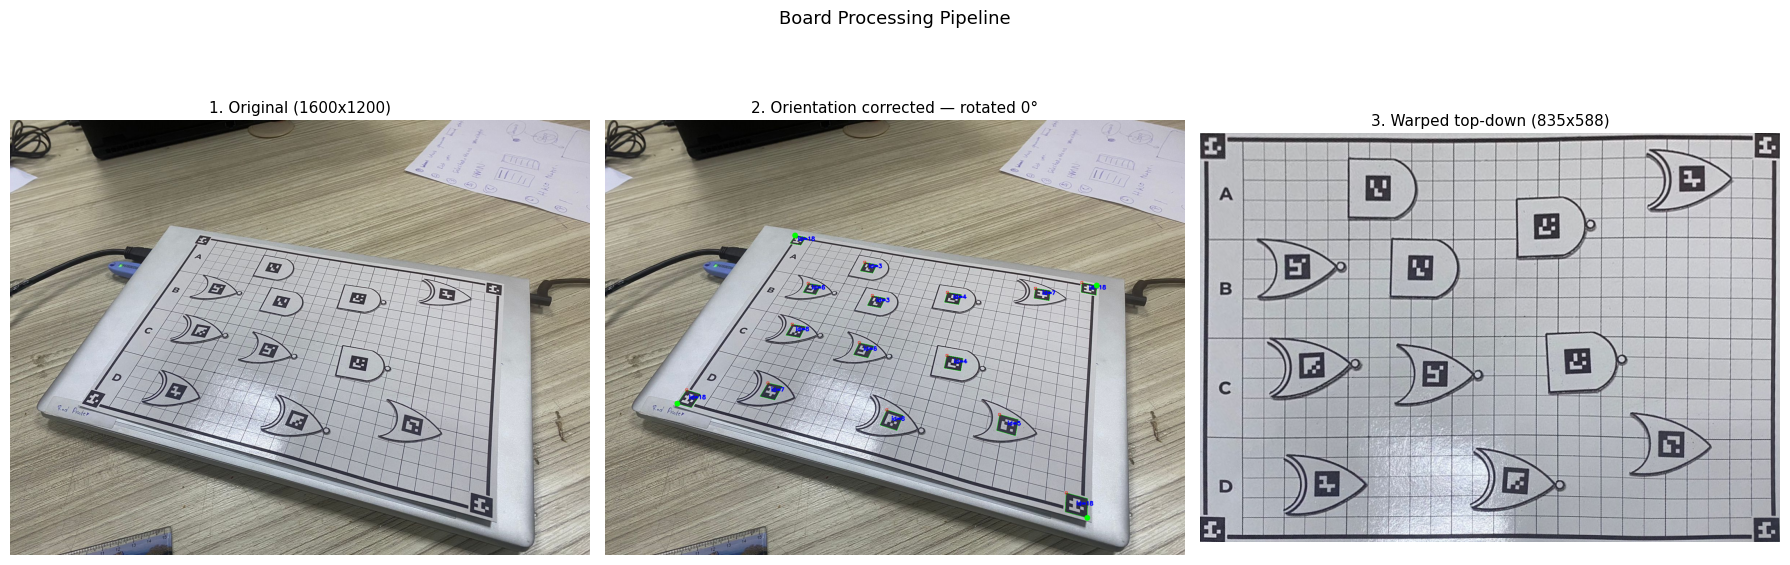

In [5]:
def process_board_image_old(image_path, output_size=(835, 588), corner_marker_id=18, show=True):
    """
    Full pipeline:
        1. Load image
        2. Correct orientation using first detected ID=18 marker
        3. Detect all 4 corner markers on the corrected image
        4. Warp to top-down view

    Parameters
    ----------
    image_path       : str   - path to input image
    output_size      : tuple - (width, height) of warped output
    corner_marker_id : int   - ArUco ID used for board corners (default 18)
    show             : bool  - display intermediate and final results

    Returns
    -------
    warped    : np.array - final top-down corrected image
    M         : np.array - homography matrix
    rotation  : int      - rotation applied in step 1 (0, 90, 180, 270)
    """

    # ── Step 1: Load ───────────────────────────────────────────────────────────
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    print("── Step 1: Image loaded ──────────────────────────────────────────")
    print(f"  Original size : {image.shape[1]}w x {image.shape[0]}h px")

    # ── Step 2: Correct orientation ────────────────────────────────────────────
    print("\n── Step 2: Correcting orientation ────────────────────────────────")
    corrected, rotation = correct_image_orientation(image, 
                                                    corner_marker_id=corner_marker_id, 
                                                    show=False)
    print(f"  Rotation applied : {rotation}°")
    print(f"  Corrected size   : {corrected.shape[1]}w x {corrected.shape[0]}h px")

    # ── Step 3: Detect markers on corrected image ──────────────────────────────
    print("\n── Step 3: Detecting corner markers ──────────────────────────────")
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(corrected)

    board_pts = order_board_corners(detected_corners, detected_ids, 
                                    corner_marker_id=corner_marker_id)

    labels = ['TL', 'TR', 'BR', 'BL']
    for label, pt in zip(labels, board_pts):
        print(f"  {label}: ({pt[0]:.1f}, {pt[1]:.1f})")

    # ── Step 4: Warp ───────────────────────────────────────────────────────────
    print("\n── Step 4: Warping to top-down view ──────────────────────────────")
    warped, M = warp_board(corrected, board_pts, output_size=output_size)
    print(f"  Output size : {warped.shape[1]}w x {warped.shape[0]}h px")

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        # Draw markers and registration points on corrected image for debug
        debug_img = corrected.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)
        for pt in board_pts.astype(int):
            cv2.circle(debug_img, tuple(pt), 8, (0, 255, 0), -1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'1. Original ({image.shape[1]}x{image.shape[0]})', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'2. Orientation corrected — rotated {rotation}°', fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f'3. Warped top-down ({output_size[0]}x{output_size[1]})', fontsize=11)
        axes[2].axis('off')

        plt.suptitle('Board Processing Pipeline', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    return warped, M, rotation


# ── Run ────────────────────────────────────────────────────────────────────────
image_path = input("Enter image path: ").strip()
warped_image, homography, rotation = process_board_image_old(image_path, output_size=(835, 588))

── Step 1: Image loaded ──────────────────────────────────────────
  Original size : 1200w x 1600h px

── Step 2: Correcting orientation ────────────────────────────────
  First ID=18 marker found at index: 0
  corner[0] position : (145.0, 1498.0)
  Marker center      : (110.2, 1535.5)
  dx=34.8, dy=-37.5
  Rotation applied   : 90°
  Rotation applied : 90°
  Corrected size   : 1600w x 1200h px

── Step 3: Detecting corner markers ──────────────────────────────
  TL: (58.0, 79.0)
  TR: (1524.0, 67.0)
  BR: (1573.0, 1123.0)
  BL: (40.0, 1124.0)

── Step 4: Warping to top-down view ──────────────────────────────
  Output size : 835w x 588h px

── Step 5: Erasing ArUco markers ──────────────────────────────────
  Markers successfully whited out.


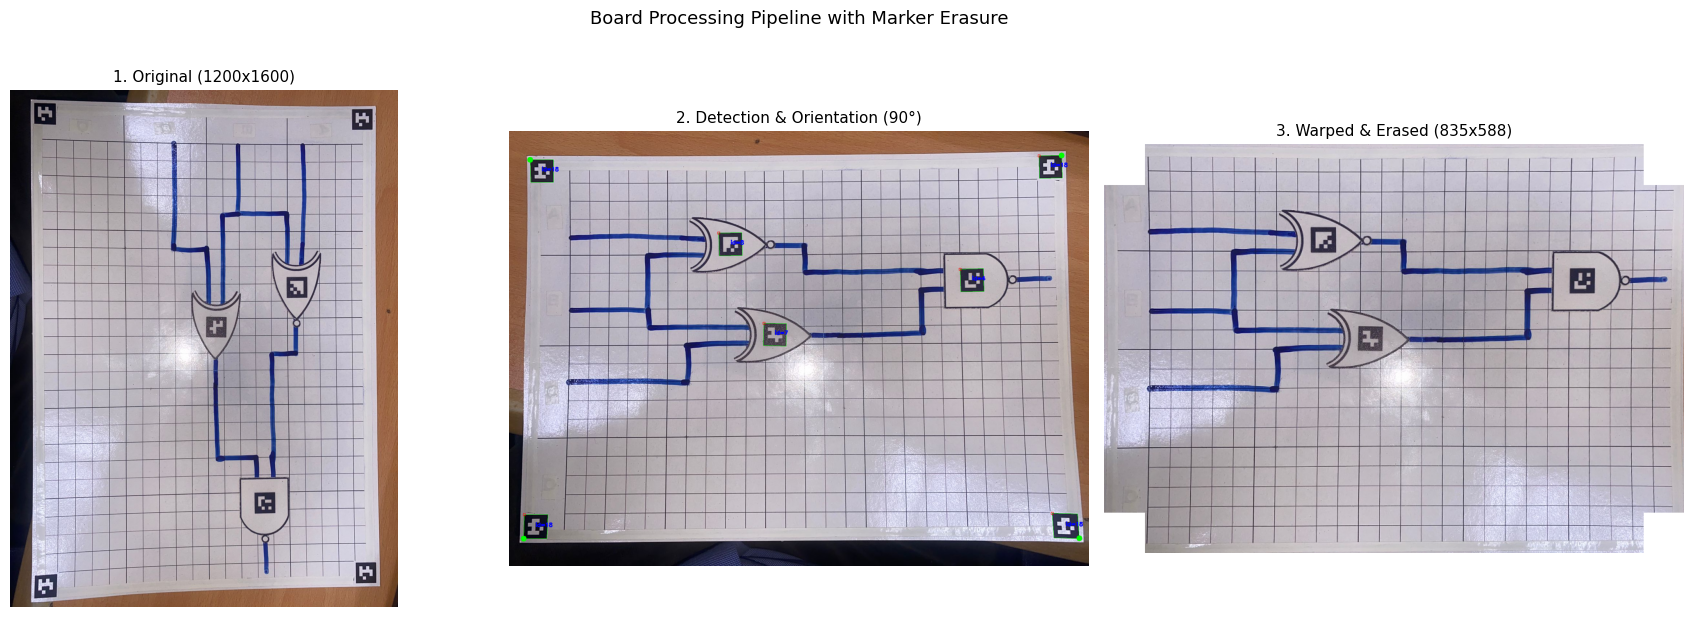

In [5]:
def process_board_image(image_path, output_size=(835, 588), corner_marker_id=18, show=True):
    """
    Full pipeline:
        1. Load image
        2. Correct orientation using first detected ID=18 marker
        3. Detect all 4 corner markers on the corrected image
        4. Warp to top-down view
        5. Erase corner markers with white boxes
    """

    # ── Step 1: Load ───────────────────────────────────────────────────────────
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    print("── Step 1: Image loaded ──────────────────────────────────────────")
    print(f"  Original size : {image.shape[1]}w x {image.shape[0]}h px")

    # ── Step 2: Correct orientation ────────────────────────────────────────────
    # Note: This assumes correct_image_orientation is defined in your environment
    print("\n── Step 2: Correcting orientation ────────────────────────────────")
    corrected, rotation = correct_image_orientation(image, 
                                                    corner_marker_id=corner_marker_id, 
                                                    show=False)
    print(f"  Rotation applied : {rotation}°")
    print(f"  Corrected size   : {corrected.shape[1]}w x {corrected.shape[0]}h px")

    # ── Step 3: Detect markers on corrected image ──────────────────────────────
    print("\n── Step 3: Detecting corner markers ──────────────────────────────")
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(corrected)

    # Note: This assumes order_board_corners is defined in your environment
    board_pts = order_board_corners(detected_corners, detected_ids, 
                                    corner_marker_id=corner_marker_id)

    labels = ['TL', 'TR', 'BR', 'BL']
    for label, pt in zip(labels, board_pts):
        print(f"  {label}: ({pt[0]:.1f}, {pt[1]:.1f})")

    # ── Step 4: Warp ───────────────────────────────────────────────────────────
    print("\n── Step 4: Warping to top-down view ──────────────────────────────")
    # Note: This assumes warp_board is defined in your environment
    warped, M = warp_board(corrected, board_pts, output_size=output_size)
    print(f"  Output size : {warped.shape[1]}w x {warped.shape[0]}h px")

    # ── Step 5: Erase Markers ──────────────────────────────────────────────────
    print("\n── Step 5: Erasing ArUco markers ──────────────────────────────────")
    out_w, out_h = output_size
    
    # We define a box size relative to the board dimensions (approx 7% of width)
    # to ensure the marker is fully covered.
    box_w = int(out_w * 0.07)
    box_h = int(out_h * 0.10)

    # Coordinates for the 4 corners: [x1, y1, x2, y2]
    rects = [
        (0, 0, box_w, box_h),                     # Top-Left
        (out_w - box_w, 0, out_w, box_h),         # Top-Right
        (out_w - box_w, out_h - box_h, out_w, out_h), # Bottom-Right
        (0, out_h - box_h, box_w, out_h)          # Bottom-Left
    ]

    for (x1, y1, x2, y2) in rects:
        cv2.rectangle(warped, (x1, y1), (x2, y2), (255, 255, 255), -1)
    
    print("  Markers successfully whited out.")

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        # Draw markers and registration points on corrected image for debug
        debug_img = corrected.copy()
        cv2.aruco.drawDetectedMarkers(debug_img, detected_corners, detected_ids)
        for pt in board_pts.astype(int):
            cv2.circle(debug_img, tuple(pt), 8, (0, 255, 0), -1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'1. Original ({image.shape[1]}x{image.shape[0]})', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'2. Detection & Orientation ({rotation}°)', fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[2].set_title(f'3. Warped & Erased ({out_w}x{out_h})', fontsize=11)
        axes[2].axis('off')

        plt.suptitle('Board Processing Pipeline with Marker Erasure', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    return warped, M, rotation

# ── Run ────────────────────────────────────────────────────────────────────────
# Ensure your helper functions (correct_image_orientation, order_board_corners, warp_board) 
# are loaded before running this.
image_path = input("Enter image path: ").strip()
warped_image, homography, rotation = process_board_image(image_path, output_size=(835, 588))

In [ ]:
cv2.imshow('Title', warped_image)
cv2.waitKey(0)

# Gate Recognition

In [6]:
def and_gate():
    """
    Returns the configuration for the AND gate.

    Returns
    -------
    dict with:
        'id'     : int  - ArUco marker ID for this gate
        'name'   : str  - gate name
        'left'   : int  - bounding box offset from center to left edge   (px)
        'right'  : int  - bounding box offset from center to right edge  (px)
        'up'     : int  - bounding box offset from center to top edge    (px)
        'down'   : int  - bounding box offset from center to bottom edge (px)
    """
    return {
        'id'   : 3,
        'name' : 'AND',
        'left' : 43,
        'right': 55,
        'up'   : 42,
        'down' : 43,
    }

def nand_gate():
    return {
        'id'   : 4,
        'name' : 'NAND',
        'left' : 45,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def or_gate():
    return {
        'id'   : 5,
        'name' : 'OR',
        'left' : 60,
        'right': 58,
        'up'   : 43,
        'down' : 45,
    }

def nor_gate():
    return {
        'id'   : 6,
        'name' : 'NOR',
        'left' : 60,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def xor_gate():
    return {
        'id'   : 7,
        'name' : 'XOR',
        'left' : 60,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

def xnor_gate():
    return {
        'id'   : 8,
        'name' : 'XNOR',
        'left' : 65,
        'right': 70,
        'up'   : 43,
        'down' : 45,
    }

── Scanning for all logic gates ──────────────────────────────────
  NAND   gate | ID=4 | center=(688,196) | bbox=(643,153,758,241)
  XNOR   gate | ID=8 | center=(315,137) | bbox=(250,94,385,182)
  XOR    gate | ID=7 | center=(383,280) | bbox=(323,237,453,325)

── Scan complete ─────────────────────────────────────────────────
  Total gates detected : 3


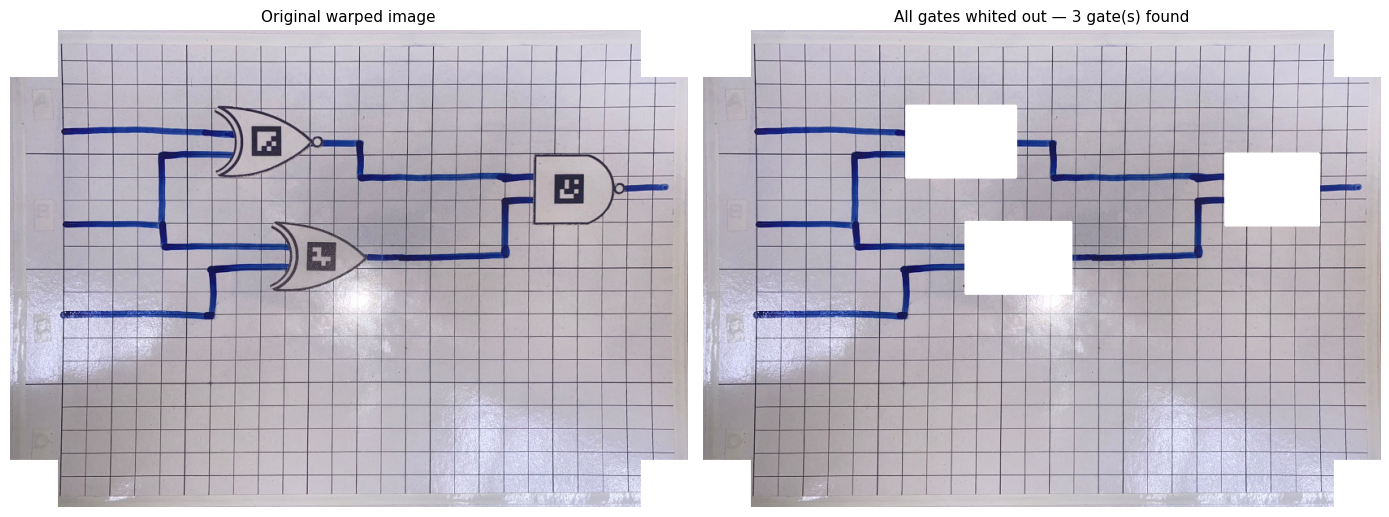

In [7]:
def scan_all_gates(warped_image, show=True):
    """
    Self-contained function that detects all logic gates in one pass,
    whites out their bounding boxes, and stores all detections.

    Parameters
    ----------
    warped_image : np.array - top-down warped board image
    show         : bool     - display original vs final result

    Returns
    -------
    board_working  : np.array - board image with all gate regions whited out
    all_detections : list     - all detected gates, each dict containing:
                                'gate'  : str        - gate name
                                'id'    : int        - ArUco ID
                                'center': (int, int) - center point
                                'bbox'  : (x1,y1,x2,y2) - bounding box
    """

    # ── Build config lookup table {aruco_id : gate_config} ────────────────────
    gate_registry = {cfg['id']: cfg for cfg in [
        and_gate(),
        nand_gate(),
        or_gate(),
        nor_gate(),
        xor_gate(),
        xnor_gate(),
    ]}

    # ── Single detection pass ──────────────────────────────────────────────────
    aruco_dict   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    aruco_params = cv2.aruco.DetectorParameters()
    detector     = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

    detected_corners, detected_ids, _ = detector.detectMarkers(warped_image)

    if detected_ids is None:
        print("  No markers detected in the image.")
        return warped_image.copy(), []

    # ── Working copy ───────────────────────────────────────────────────────────
    board_working  = warped_image.copy()
    all_detections = []
    h, w           = board_working.shape[:2]

    print("── Scanning for all logic gates ──────────────────────────────────")

    # ── Single loop through all detected markers ───────────────────────────────
    for i, marker_id in enumerate(detected_ids.flatten()):

        # Skip if this ID is not a gate we recognise (e.g. corner marker ID=18)
        if marker_id not in gate_registry:
            continue

        config = gate_registry[marker_id]

        # ── Compute center ─────────────────────────────────────────────────────
        pts    = detected_corners[i].reshape(4, 2)
        center = pts.mean(axis=0)
        cx     = int(round(center[0]))
        cy     = int(round(center[1]))

        # ── Bounding box ───────────────────────────────────────────────────────
        x1 = max(0, cx - config['left'])
        y1 = max(0, cy - config['up'])
        x2 = min(w,  cx + config['right'])
        y2 = min(h,  cy + config['down'])

        # ── White out region + border ──────────────────────────────────────────
        board_working[y1:y2, x1:x2] = 255
        cv2.rectangle(board_working, (x1, y1), (x2, y2), (255, 255, 255), 2)

        # ── Store detection ────────────────────────────────────────────────────
        all_detections.append({
            'gate'  : config['name'],
            'id'    : marker_id,
            'center': (cx, cy),
            'bbox'  : (x1, y1, x2, y2),
        })

        print(f"  {config['name']:6s} gate | ID={marker_id} | "f"center=({cx},{cy}) | "f"bbox=({x1},{y1},{x2},{y2})")

    # ── Summary ────────────────────────────────────────────────────────────────
    print(f"\n── Scan complete ─────────────────────────────────────────────────")
    print(f"  Total gates detected : {len(all_detections)}")

    # ── Display ────────────────────────────────────────────────────────────────
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original warped image', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(board_working, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'All gates whited out — {len(all_detections)} gate(s) found', fontsize=11)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return board_working, all_detections


# ── Run ────────────────────────────────────────────────────────────────────────
board_working, all_detections = scan_all_gates(warped_image, show=True)

## Thresholding

Square Grid Kernel Thresholding

In [ ]:
def tune_Square_threshold(warped_image):
    """
    Displays a grid of adaptive threshold results with different
    block_size and C combinations to help find the best values.
    """

    gray = cv2.cvtColor(warped_image, cv2.COLOR_BGR2GRAY)

    block_sizes = [21, 51, 151]
    C_values    = [5, 10, 60]

    fig, axes = plt.subplots(len(block_sizes), len(C_values), figsize=(14, 12))
    fig.suptitle('Adaptive threshold tuning — block_size (rows) vs C (columns)', fontsize=13)

    for r, block_size in enumerate(block_sizes):
        for c, C in enumerate(C_values):
            thresh = cv2.adaptiveThreshold(
                gray,
                maxValue       = 255,
                adaptiveMethod = cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                thresholdType  = cv2.THRESH_BINARY,
                blockSize      = block_size,
                C              = C
            )
            axes[r, c].imshow(thresh, cmap='gray')
            axes[r, c].set_title(f'block={block_size}, C={C}', fontsize=10)
            axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
tune_Square_threshold(board_working)

Circle grid kernel thresholding

In [ ]:
def tune_Circle_threshold(warped_image):
    gray = cv2.cvtColor(warped_image, cv2.COLOR_BGR2GRAY)

    block_sizes = [21, 51, 201]
    C_values    = [5, 10, 60]

    fig, axes = plt.subplots(len(block_sizes), len(C_values), figsize=(14, 12))
    fig.suptitle('Adaptive threshold tuning — circular kernel (rows=block_size, cols=C)', fontsize=13)

    for r, block_size in enumerate(block_sizes):

        # ── Build circular kernel of size block_size x block_size ──────────────
        radius  = block_size // 2
        y, x    = np.ogrid[-radius:radius+1, -radius:radius+1]
        circle  = (x**2 + y**2 <= radius**2).astype(np.float32)
        kernel  = circle / circle.sum()   # normalize so weights sum to 1

        # ── Compute local mean using circular kernel via filter2D ───────────────
        local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)

        for c, C in enumerate(C_values):

            # ── Threshold: pixel > (local_mean - C) → white, else black ────────
            thresh = np.where(gray > (local_mean - C), 255, 0).astype(np.uint8)

            axes[r, c].imshow(thresh, cmap='gray')
            axes[r, c].set_title(f'block={block_size}, C={C}', fontsize=10)
            axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
tune_Circle_threshold(board_working)

Cross grid kernel thresholding

In [ ]:
def tune_Cross_threshold(warped_image):
    gray = cv2.cvtColor(warped_image, cv2.COLOR_BGR2GRAY)

    block_sizes = [21, 51, 251]
    C_values    = [5, 20, 60]

    fig, axes = plt.subplots(len(block_sizes), len(C_values), figsize=(14, 12))
    fig.suptitle('Adaptive threshold tuning — cross kernel (rows=block_size, cols=C)', fontsize=13)

    for r, block_size in enumerate(block_sizes):

        # ── Build cross kernel of size block_size x block_size ─────────────────
        kernel      = np.zeros((block_size, block_size), dtype=np.float32)
        mid         = block_size // 2
        kernel[mid, :]  = 1   # horizontal bar
        kernel[:, mid]  = 1   # vertical bar
        kernel      = kernel / kernel.sum()   # normalize

        # ── Compute local mean using cross kernel via filter2D ──────────────────
        local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)

        for c, C in enumerate(C_values):

            # ── Threshold ───────────────────────────────────────────────────────
            thresh = np.where(gray > (local_mean - C), 255, 0).astype(np.uint8)

            axes[r, c].imshow(thresh, cmap='gray')
            axes[r, c].set_title(f'block={block_size}, C={C}', fontsize=10)
            axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
tune_Cross_threshold(board_working)

In [8]:
def Final_threshold(warped_image, block_size, C):
    gray = cv2.cvtColor(warped_image, cv2.COLOR_BGR2GRAY)

    radius = block_size // 2
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    circle = (x**2 + y**2 <= radius**2).astype(np.float32)
    kernel = circle / circle.sum()

    local_mean = cv2.filter2D(gray.astype(np.float32), -1, kernel)
    thresh = np.where(gray > (local_mean - C), 255, 0).astype(np.uint8)

    plt.figure(figsize=(8, 6))
    plt.imshow(thresh, cmap='gray')
    plt.title(f'block={block_size}, C={C}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return thresh

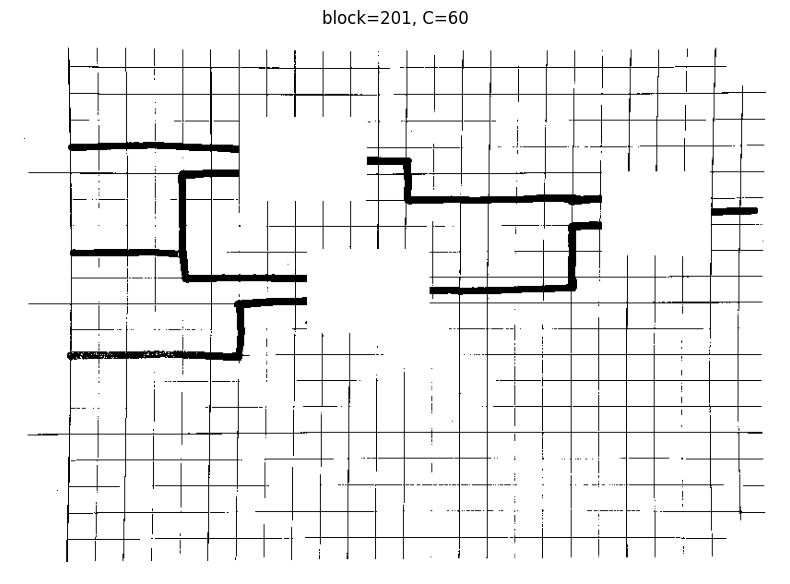

In [9]:
thresh = Final_threshold(board_working, block_size=201, C=60)

## Morphological Opening

In [10]:
def apply_morphology(thresh_image, k):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

    opened = cv2.morphologyEx(thresh_image, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(thresh_image, cv2.MORPH_CLOSE, kernel)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(thresh_image, cmap='gray')
    axes[0].set_title('Original Threshold')
    axes[0].axis('off')

    axes[1].imshow(opened, cmap='gray')
    axes[1].set_title('After Opening')
    axes[1].axis('off')

    axes[2].imshow(closed, cmap='gray')
    axes[2].set_title('After Closing')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return opened, closed

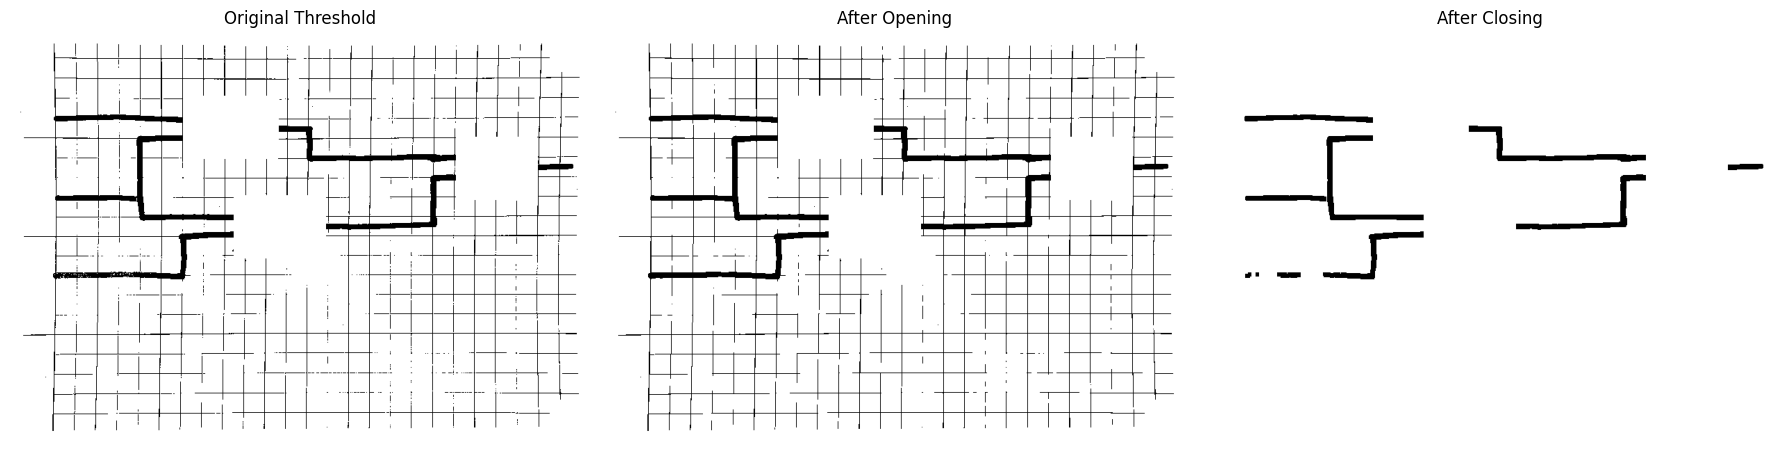

In [11]:
opened, closed = apply_morphology(thresh, k=5)

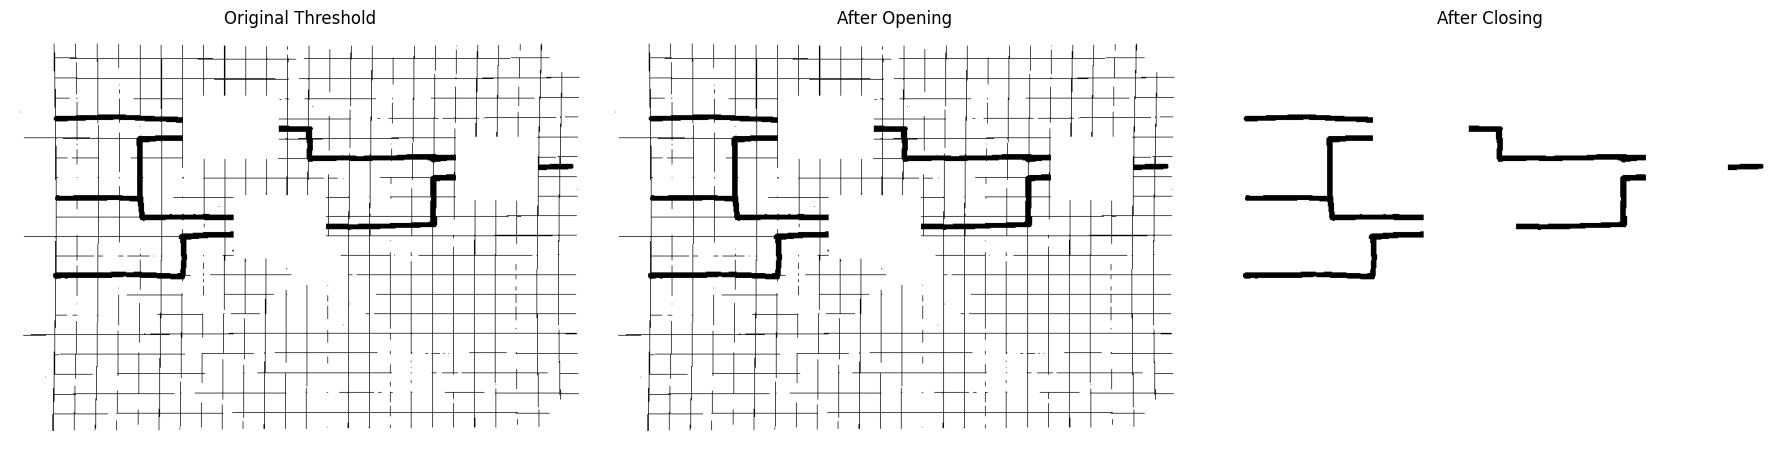

In [12]:
opened1, closed2 = apply_morphology(opened, k=3)

# Line Identification

## Smoothing

__Median Blur__ (using)

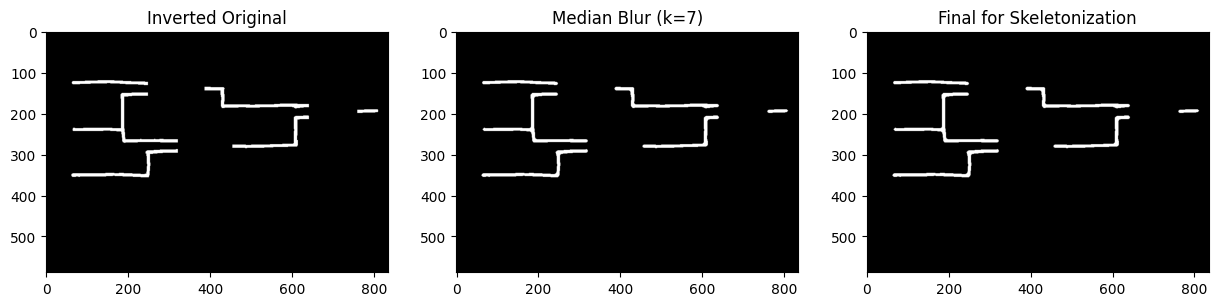

In [13]:
def median_smoothing_pipeline(img, ksize=7):
    """
    Smoothing handwritten lines using Median Blur to prevent webbing.
    """
    # 1. Ensure it's inverted (Wires should be White)
    # If your 'closed2' is black wires on white background:
    if np.mean(img) > 127: 
        working_img = cv2.bitwise_not(img)
    else:
        working_img = img.copy()

    # 2. Median Blur 
    # ksize must be an odd integer (3, 5, 7, 9...)
    # Larger ksize = more smoothing of 'shaky' hand lines
    smoothed = cv2.medianBlur(working_img, ksize)

    # 3. Threshold to clean up the edges
    _, binary = cv2.threshold(smoothed, 127, 255, cv2.THRESH_BINARY)

    # 4. Visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(working_img, cmap='gray')
    plt.title("Inverted Original")
    
    plt.subplot(1, 3, 2)
    plt.imshow(smoothed, cmap='gray')
    plt.title(f"Median Blur (k={ksize})")
    
    plt.subplot(1, 3, 3)
    plt.imshow(binary, cmap='gray')
    plt.title("Final for Skeletonization")
    plt.show()

    return binary

# --- Run the Test ---
# Try ksize=7 or 9 for handwritten lines. 
# It should make them look like smooth "noodles" without the fuzzy edges.
smoothed_lines = median_smoothing_pipeline(closed2, ksize=7)

Gaussian Blur Loop

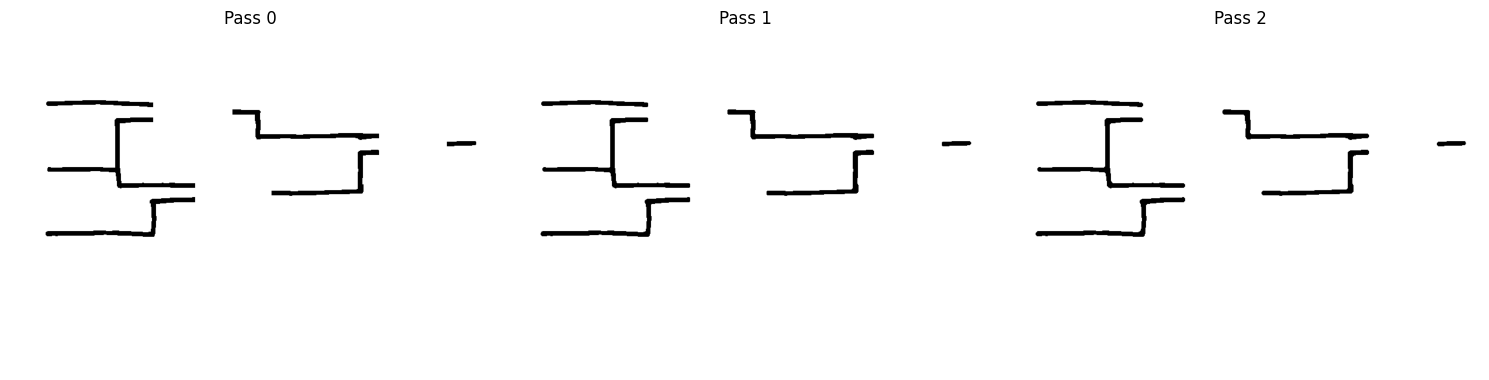

In [23]:
def iterative_smoothing(img, iterations=5, ksize=(5, 5), threshold_val=127):
    """
    Blurs and thresholds an image multiple times to smooth out 
    handwritten 'jagged' edges before skeletonization.
    """
    working_img = img.copy()
    
    # Track the steps for visualization
    history = [img.copy()]
    
    for i in range(iterations):
        # 1. Apply Gaussian Blur to 'bleed' the edges and smooth noise
        working_img = cv2.GaussianBlur(working_img, ksize, 0)
        
        # 2. Threshold to snap the 'gray' blurred edges back to black or white
        _, working_img = cv2.threshold(working_img, threshold_val, 255, cv2.THRESH_BINARY)
        
        history.append(working_img.copy())
    
    # ── Display the progression ──
    plt.figure(figsize=(15, 10))
    for idx, step_img in enumerate(history):
        plt.subplot(1, iterations + 1, idx + 1)
        plt.imshow(step_img, cmap='gray')
        plt.title(f"Pass {idx}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return working_img

# ── How to Run ──
# Start with a 5x5 kernel. If it's not smoothing enough, try 7x7 or 9x9.
# If the lines are disappearing, lower the iterations to 2 or 3.
smoothed_lines = iterative_smoothing(closed2, iterations=2, ksize=(7, 7))

# Circuit Identification - Method1

## Connective Line Skeleton

In [14]:
def opencv_skeleton_healed(binary_img):
    # 1. Standardize
    if len(binary_img.shape) > 2:
        img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
    else:
        img = cv2.bitwise_not(binary_img)
    
    # Standardize and INVERT (so wires are white)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # ── STEP A: HEAL (Before the Loop) ──────────────────────────────────────
    # We use a small dilation to bridge gaps in T-junctions and split ends
    heal_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    temp_img = cv2.dilate(img, heal_kernel, iterations=1)
    # Closing fills small holes inside the lines
    temp_img = cv2.morphologyEx(temp_img, cv2.MORPH_CLOSE, heal_kernel)

    skel = np.zeros(img.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    done = False
    
    while not done:
        # 1. Erode
        eroded = cv2.erode(temp_img, element)
        
        # 2. Dilate back
        temp = cv2.dilate(eroded, element)
        
        # 3. Subtract to find the structure lost
        temp = cv2.subtract(temp_img, temp)
        
        # ── STEP B: CLEAN RESIDUE (Inside the Loop) ─────────────────────────
        # Instead of blurring the whole image (which breaks the loop),
        # we can 'clean' the captured skeleton piece if it's too noisy.
        # This keeps the skeleton lines sharp.
        
        # 4. Add to skeleton
        skel = cv2.bitwise_or(skel, temp)
        temp_img = eroded.copy()
        
        if cv2.countNonZero(temp_img) == 0:
            done = True

    # ── Visualization ──
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Original Inverted")
    plt.subplot(1, 2, 2); plt.imshow(skel, cmap='gray'); plt.title("Healed Skeleton")
    plt.show()
    
    return skel

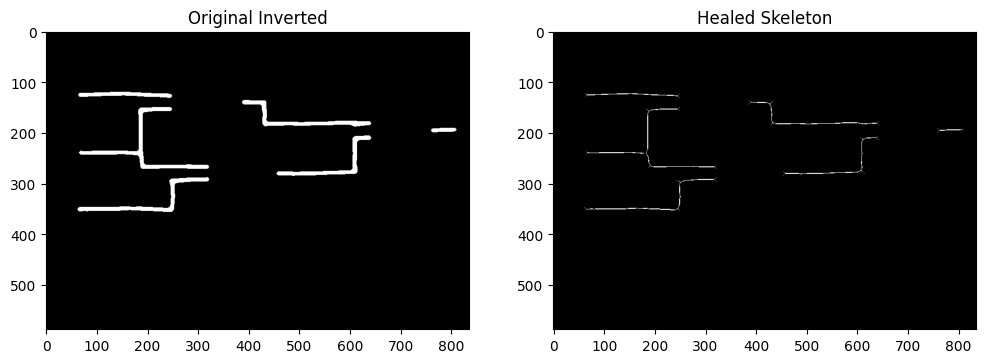

In [15]:
skel = opencv_skeleton_healed(smoothed_lines)

Skeleton Step debug visualization

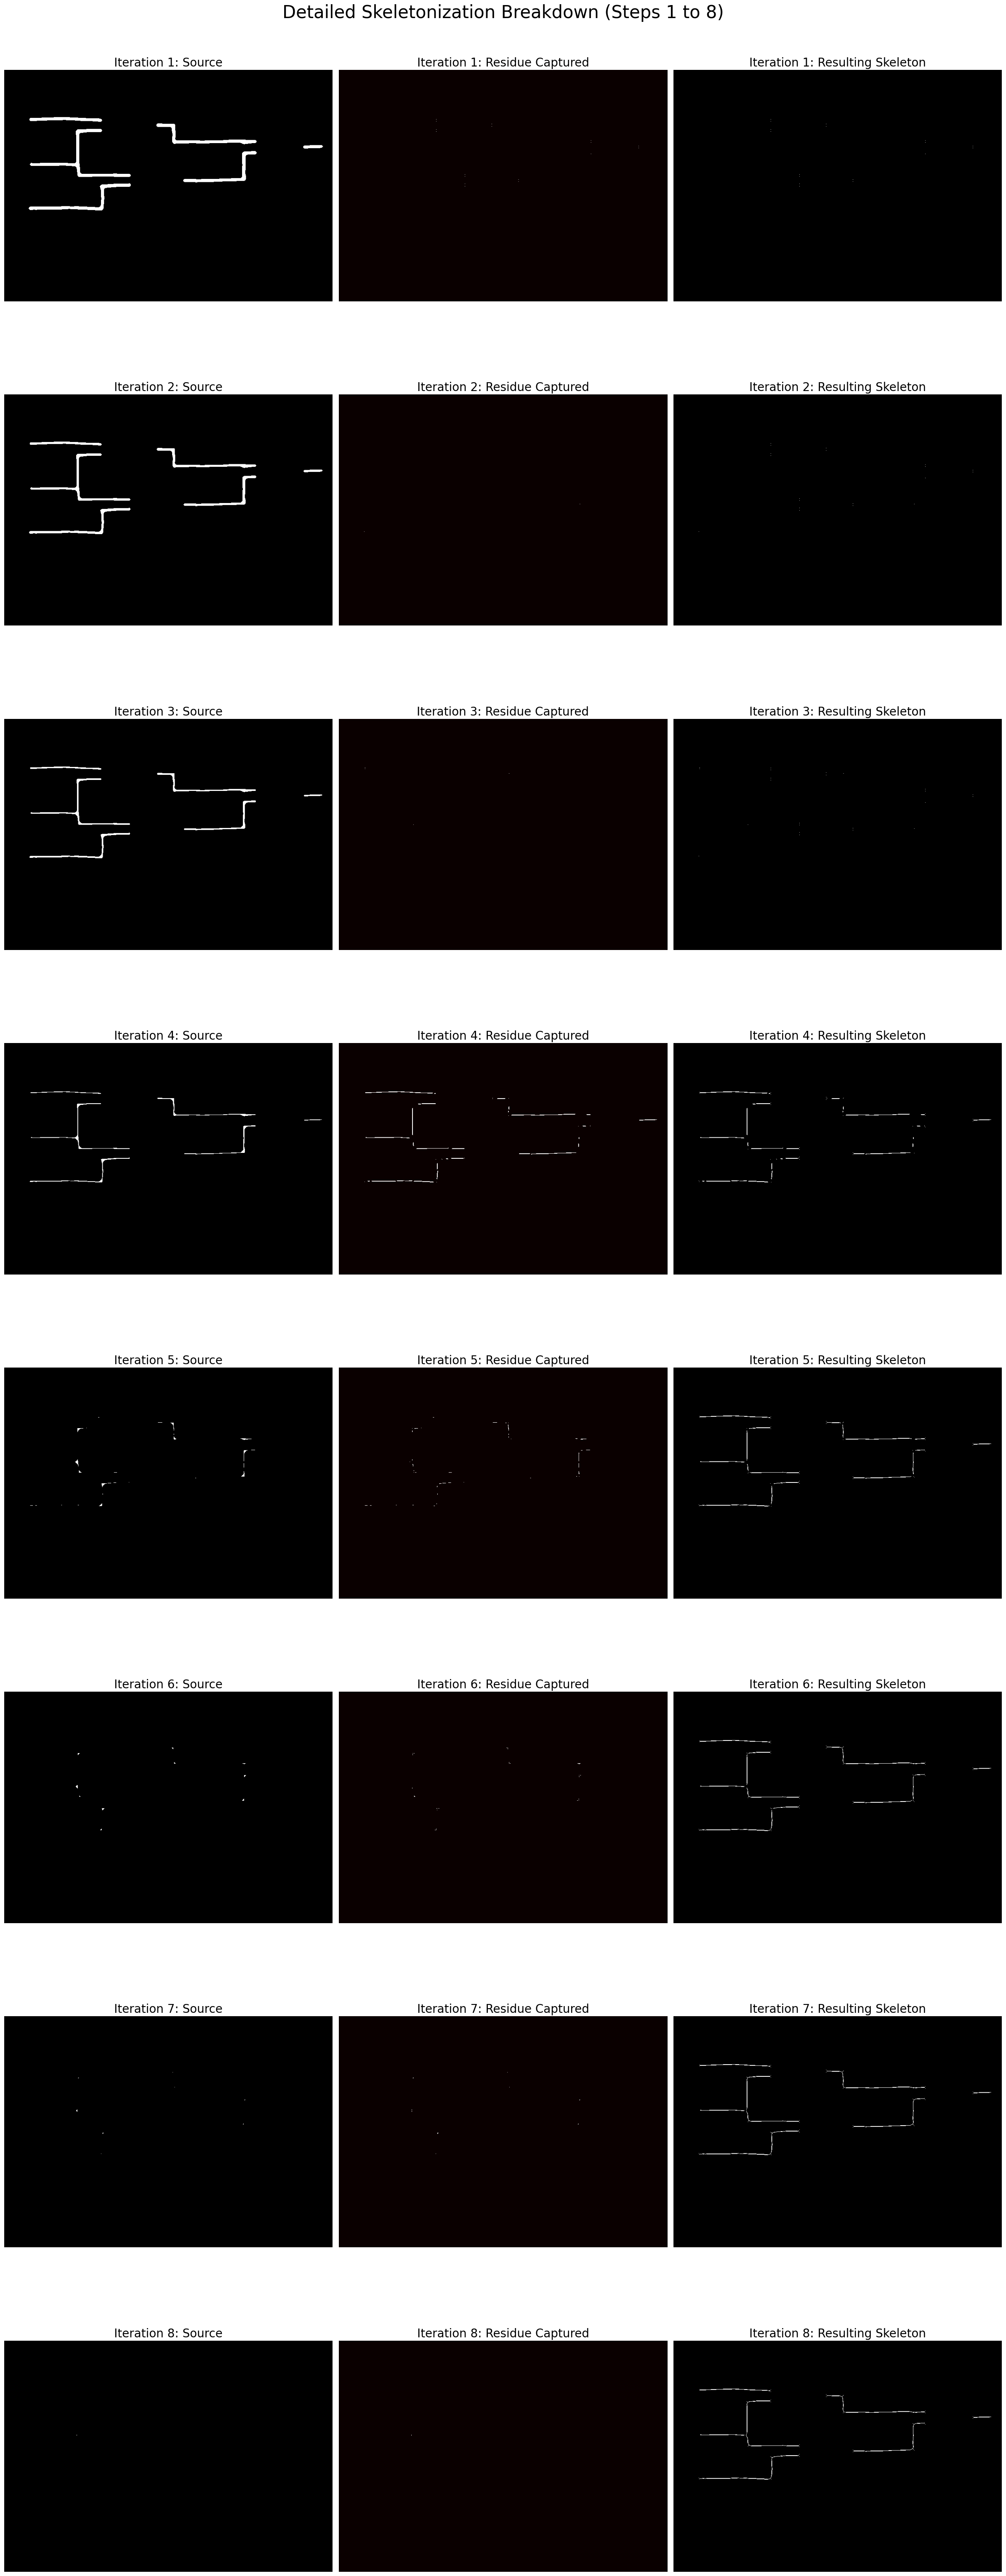

In [22]:
def debug_opencv_skeleton_large(binary_img, max_viz_steps=8):
    """
    Vertical layout with large images for high-detail diagnosis.
    """
    # 1. Standardize Input
    if len(binary_img.shape) > 2:
        img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
    else:
        img = binary_img.copy()
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # 2. Setup variables
    skel = np.zeros(img.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    
    # IMPORTANT: Ensure wires are WHITE (255) for the logic
    # If your original was black on white, bitwise_not makes it white on black
    #temp_img = cv2.bitwise_not(img)
    temp_img = img.copy()
    
    history = [] # Will store (Working_Img, Residue, Current_Skel)
    
    iteration = 0
    done = False
    
    while not done:
        iteration += 1
        
        # A. Erode 
        eroded = cv2.erode(temp_img, element)
        
        # B. Dilate back to find what was lost
        temp = cv2.dilate(eroded, element)
        
        # C. Subtract to find the 'bones' of THIS step
        residue = cv2.subtract(temp_img, temp)
        
        # D. Add to final skeleton
        skel = cv2.bitwise_or(skel, residue)
        
        if iteration <= max_viz_steps:
            history.append((temp_img.copy(), residue.copy(), skel.copy()))
        
        temp_img = eroded.copy()
        if cv2.countNonZero(temp_img) == 0:
            done = True

    # ── BIG VISUALIZATION ──
    steps_to_show = len(history)
    # 3 columns: Source of step, Residue found, Total Skeleton so far
    fig, axes = plt.subplots(steps_to_show, 3, figsize=(24, 8 * steps_to_show))
    
    # Handle single iteration case for subplots
    if steps_to_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(steps_to_show):
        src, res, tot = history[i]
        
        # Col 1: Working Image
        axes[i, 0].imshow(src, cmap='gray')
        axes[i, 0].set_title(f"Iteration {i+1}: Source", fontsize=20)
        axes[i, 0].axis('off')
        
        # Col 2: The 'Bones' captured in this pass
        axes[i, 1].imshow(res, cmap='hot') # Hot map makes tiny noise pixels pop
        axes[i, 1].set_title(f"Iteration {i+1}: Residue Captured", fontsize=20)
        axes[i, 1].axis('off')
        
        # Col 3: Cumulative Skeleton
        axes[i, 2].imshow(tot, cmap='gray')
        axes[i, 2].set_title(f"Iteration {i+1}: Resulting Skeleton", fontsize=20)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.98)
    fig.suptitle(f"Detailed Skeletonization Breakdown (Steps 1 to {steps_to_show})", fontsize=30)
    plt.show()
    
    return skel

# Run it
try:
    # Use a lower max_viz_steps if it takes too much screen space, e.g., 6 or 8
    final_skel = debug_opencv_skeleton_large(clean_for_skel, max_viz_steps=10)
except Exception as e:
    print(f"Error: {e}")

Heal Skeleton

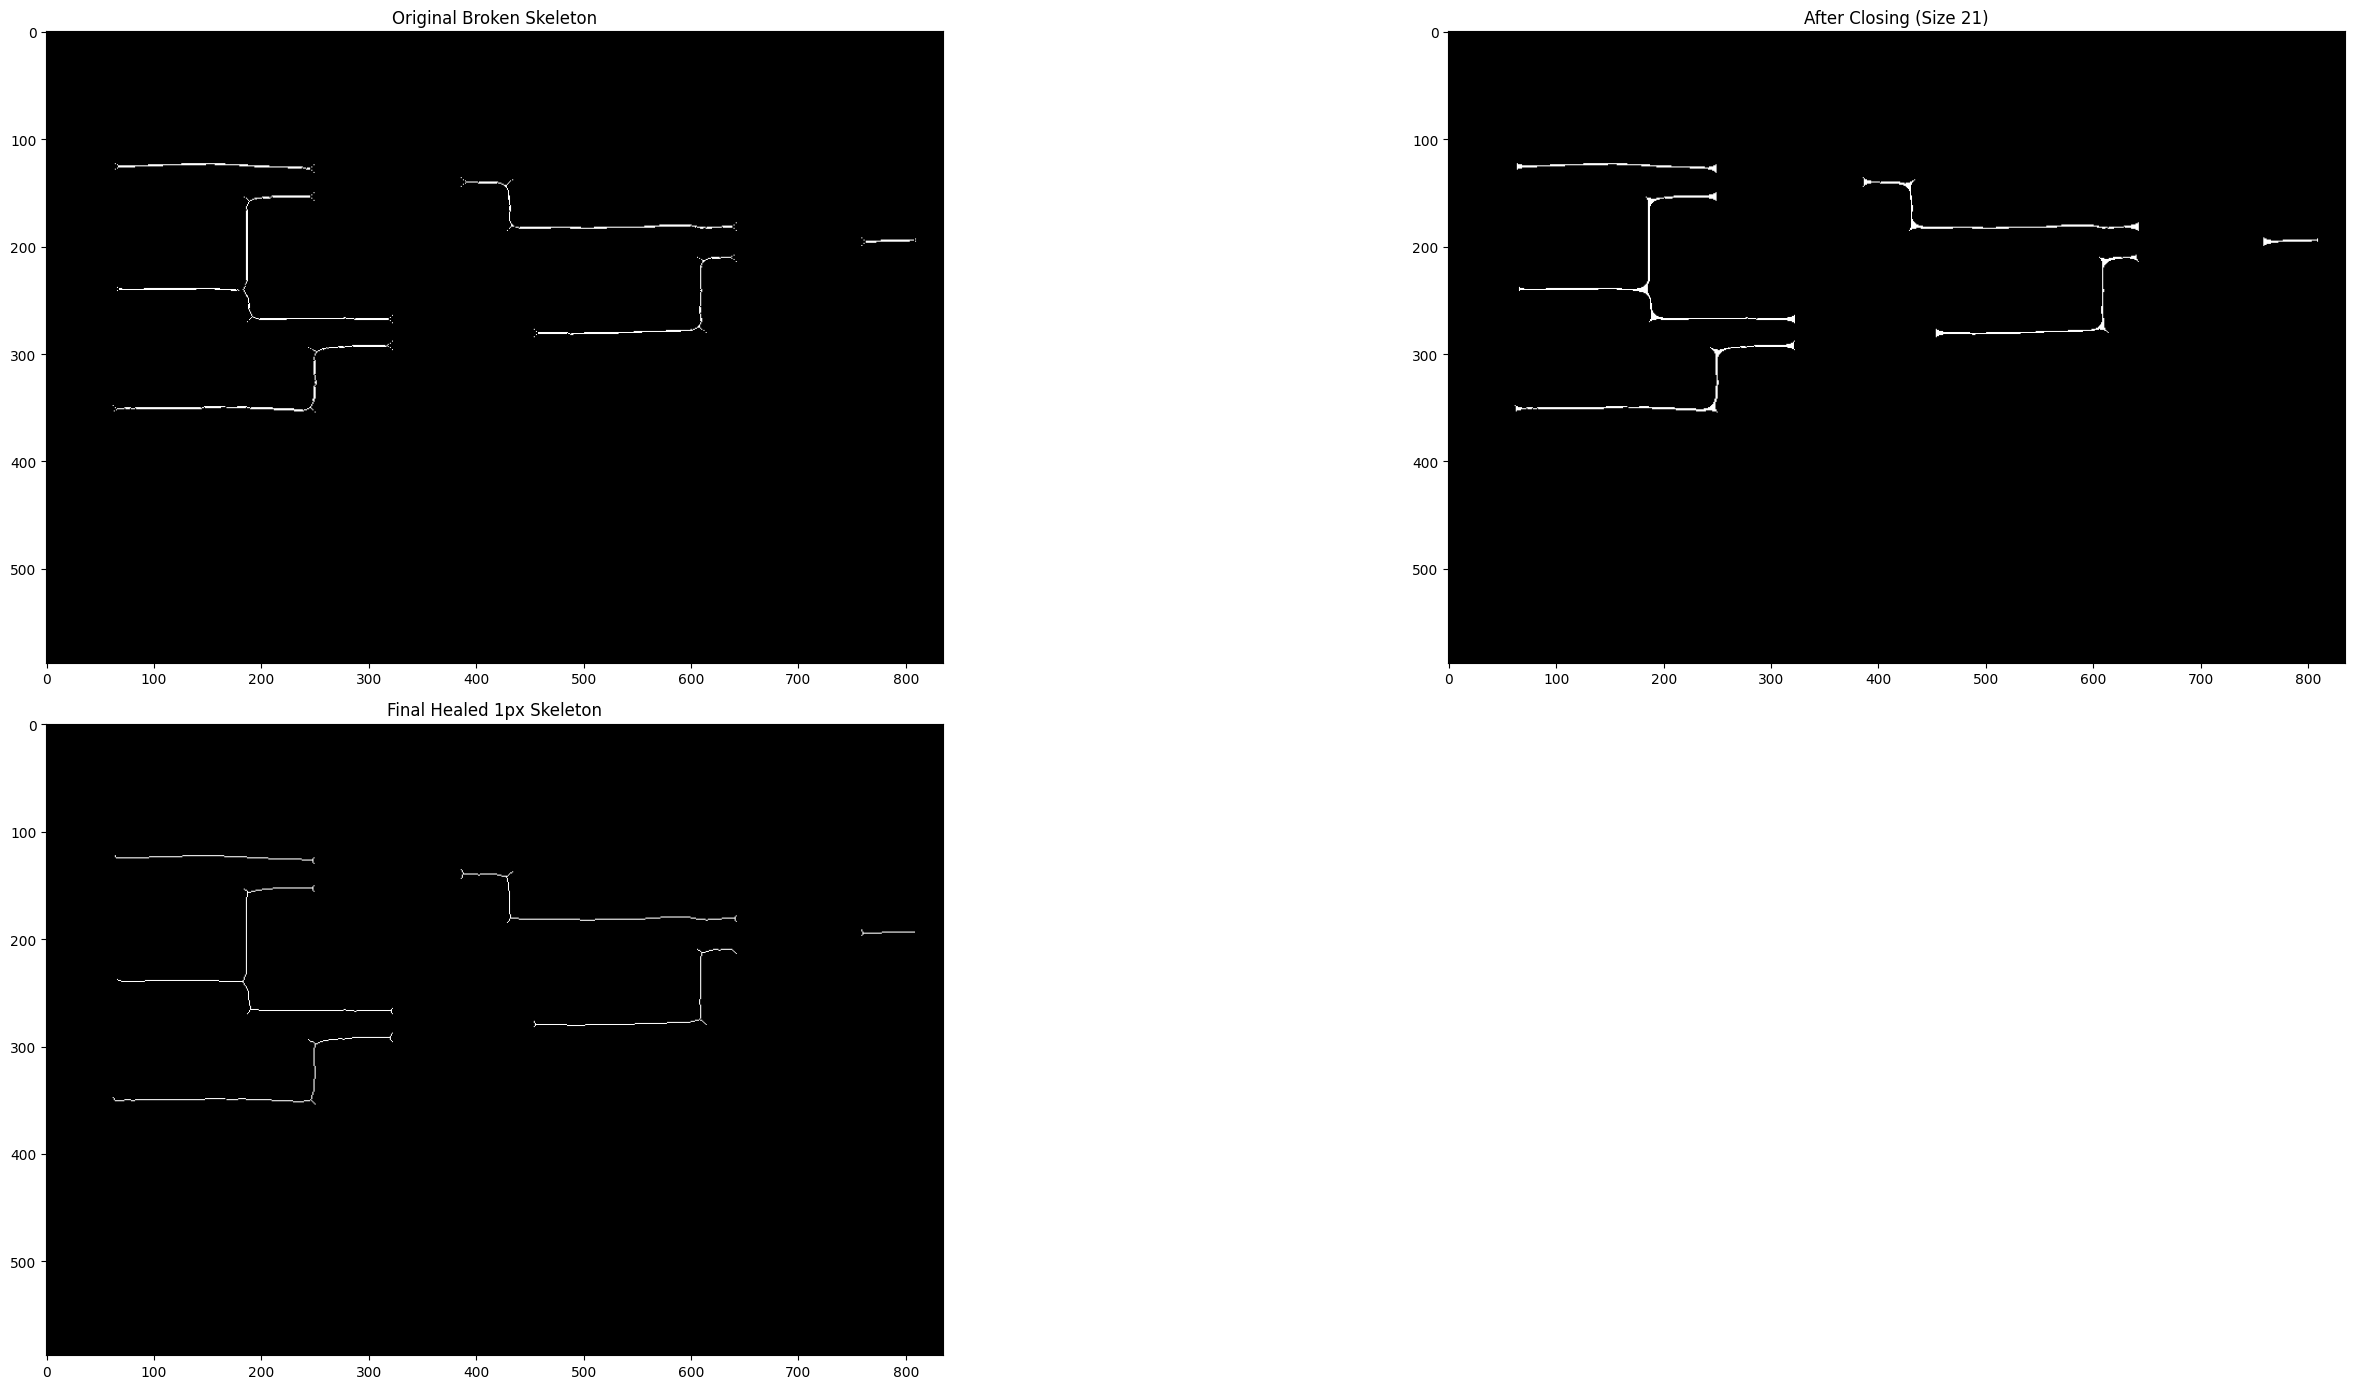

In [17]:
def heal_skeleton(skel_img, kernel_size=3, iterations=1):
    """
    Morphologically closes a skeleton to bridge gaps.
    
    Args:
        skel_img: The 1-pixel wide skeleton image (white lines on black).
        kernel_size: Size of the closing window. Larger = bridges bigger gaps.
        iterations: Number of times to apply the closing.
    """
    # 1. Create the kernel
    # ELLIPSE is usually better for hand-drawn junctions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # 2. Apply Morphological Closing
    # This Dilates (bridges gaps) then Erodes (tries to restore thickness)
    closed_skel = cv2.morphologyEx(skel_img, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    
    # 3. Re-Skeletonize (Optional but Recommended)
    # Closing often makes the lines 2-3 pixels thick at the junctions.
    # We re-run a quick thinning to ensure it's 1-pixel wide again.
    from skimage.morphology import skeletonize # Using skimage if available for speed
    healed_skel = skeletonize(closed_skel > 0).astype(np.uint8) * 255
    
    # ── Visualization ──
    plt.figure(figsize=(30, 14))
    plt.subplot(2, 2, 1)
    plt.imshow(skel_img, cmap='gray')
    plt.title("Original Broken Skeleton")
    
    plt.subplot(2, 2, 2)
    plt.imshow(closed_skel, cmap='gray')
    plt.title(f"After Closing (Size {kernel_size})")
    
    plt.subplot(2, 2, 3)
    plt.imshow(healed_skel, cmap='gray')
    plt.title("Final Healed 1px Skeleton")
    
    plt.tight_layout()
    plt.show()
    
    return healed_skel

# --- How to use ---
# Start with 3 or 5. If the gaps are still there, go up to 7 or 9.
healed_output = heal_skeleton(skel, kernel_size=21)

## Endpoints and Junction Identification

Initial Endpoints and Junctions Identification

In [31]:
from skimage.morphology import thin
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def extract_circuit_features(skel, warped_image=None):
    skel = (thin(skel > 0) * 255).astype(np.uint8)

    num_labels, labels = cv2.connectedComponents(skel)

    base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB) if warped_image is not None else cv2.cvtColor(skel, cv2.COLOR_GRAY2BGR)
    vis_img = base.copy()

    padded_skel = np.pad(skel, 1, mode='constant', constant_values=0)
    white_pixels = np.argwhere(skel > 0)

    wire_data = {}
    for wire_id in range(1, num_labels):
        wire_data[wire_id] = {'endpoints': [], 'junctions': []}

    for y, x in white_pixels:
        neighborhood = padded_skel[y:y+3, x:x+3]
        neighbor_count = np.sum(neighborhood > 0) - 1
        wire_id = int(labels[y, x])

        if neighbor_count == 1:
            wire_data[wire_id]['endpoints'].append((x, y))
            cv2.circle(vis_img, (x, y), 1, (0, 0, 255), -1)    # Blue = endpoint

        elif neighbor_count >= 3:
            wire_data[wire_id]['junctions'].append((x, y))
            cv2.circle(vis_img, (x, y), 1, (0, 255, 0), -1)    # Green = junction

    blue_patch  = mpatches.Patch(color='blue',  label='Endpoint')
    green_patch = mpatches.Patch(color='green', label='Junction')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title('Circuit Features: Blue=Endpoint  Green=Junction')
    plt.legend(handles=[blue_patch, green_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    for wire_id, data in wire_data.items():
        wid = f"Wire{wire_id:02d}"

        if data['endpoints']:
            ep_str = ', '.join(f"EP{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['endpoints']))
        else:
            ep_str = '-'

        if data['junctions']:
            junc_str = ', '.join(f"JUNC{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['junctions']))
        else:
            junc_str = '-'

        print(f"{wid} --- {ep_str} --- {junc_str}")

    return wire_data, labels

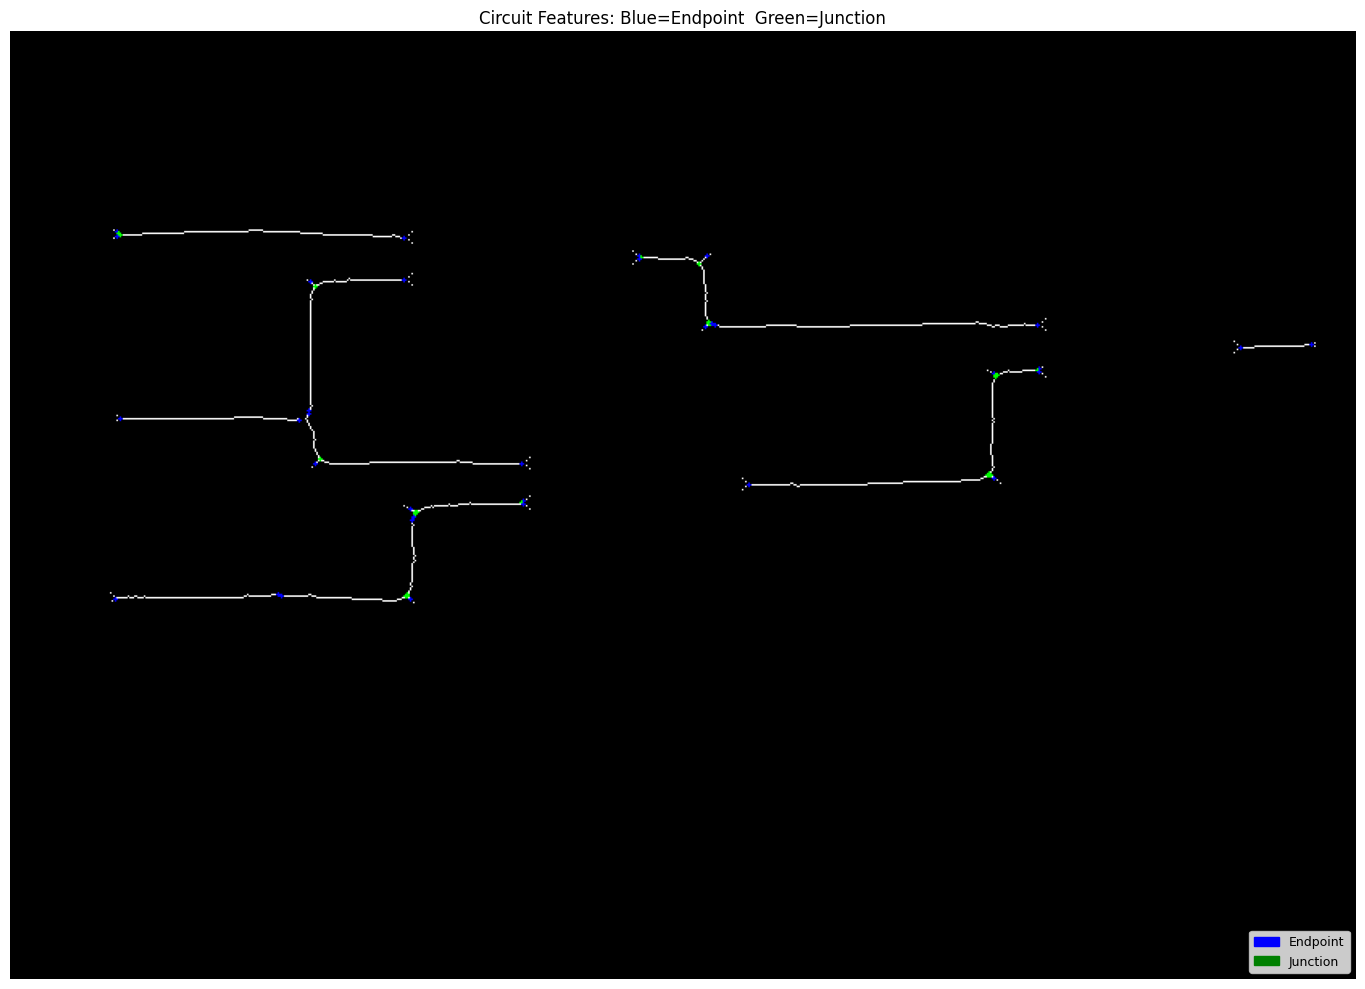

Wire01 --- - --- -
Wire02 --- EP02.1 (np.int64(66), np.int64(124)), EP02.2 (np.int64(66), np.int64(127)), EP02.3 (np.int64(244), np.int64(128)) --- JUNC02.1 (np.int64(67), np.int64(125)), JUNC02.2 (np.int64(67), np.int64(126)), JUNC02.3 (np.int64(68), np.int64(126))
Wire03 --- - --- -
Wire04 --- - --- -
Wire05 --- - --- -
Wire06 --- - --- -
Wire07 --- - --- -
Wire08 --- - --- -
Wire09 --- - --- -
Wire10 --- EP10.1 (np.int64(390), np.int64(139)), EP10.2 (np.int64(432), np.int64(139)), EP10.3 (np.int64(390), np.int64(141)), EP10.4 (np.int64(435), np.int64(181)), EP10.5 (np.int64(431), np.int64(183)) --- JUNC10.1 (np.int64(391), np.int64(140)), JUNC10.2 (np.int64(427), np.int64(144)), JUNC10.3 (np.int64(433), np.int64(180)), JUNC10.4 (np.int64(433), np.int64(181)), JUNC10.5 (np.int64(434), np.int64(181))
Wire11 --- - --- -
Wire12 --- - --- -
Wire13 --- - --- -
Wire14 --- - --- -
Wire15 --- EP15.1 (np.int64(244), np.int64(154)), EP15.2 (np.int64(186), np.int64(155)), EP15.3 (np.int64(185),

In [32]:
wire_data, labels = extract_circuit_features(skel, warped_image=None)

In [33]:
from skimage.morphology import thin

def extract_circuit_features(skel):
    # 1. FORCE THINNING
    # This collapses 2-pixel thick lines into 1-pixel lines
    # so that neighbor counting actually works.
    skel = (thin(skel > 0) * 255).astype(np.uint8)
    
    # 2. Label each unique wire
    num_labels, labels = cv2.connectedComponents(skel)
    vis_img = cv2.cvtColor(skel, cv2.COLOR_GRAY2BGR)
    
    endpoints = []
    junctions = []
    white_pixels = np.argwhere(skel > 0)
    padded_skel = np.pad(skel, 1, mode='constant', constant_values=0)
    
    for y, x in white_pixels:
        # Check neighbors in the 1-pixel thin version
        neighborhood = padded_skel[y:y+3, x:x+3]
        neighbor_count = np.sum(neighborhood > 0) - 1
        
        if neighbor_count == 1:
            endpoints.append((x, y))
            cv2.circle(vis_img, (x, y), 3, (255, 0, 0), -1) # Blue
        elif neighbor_count >= 3:
            junctions.append((x, y))
            cv2.circle(vis_img, (x, y), 3, (0, 255, 0), -1) # Green
            
    # ── Visualization ──
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title("Fixed Analysis: Should now only have Green dots at T-junctions")
    plt.show()
    
    return endpoints, junctions, labels

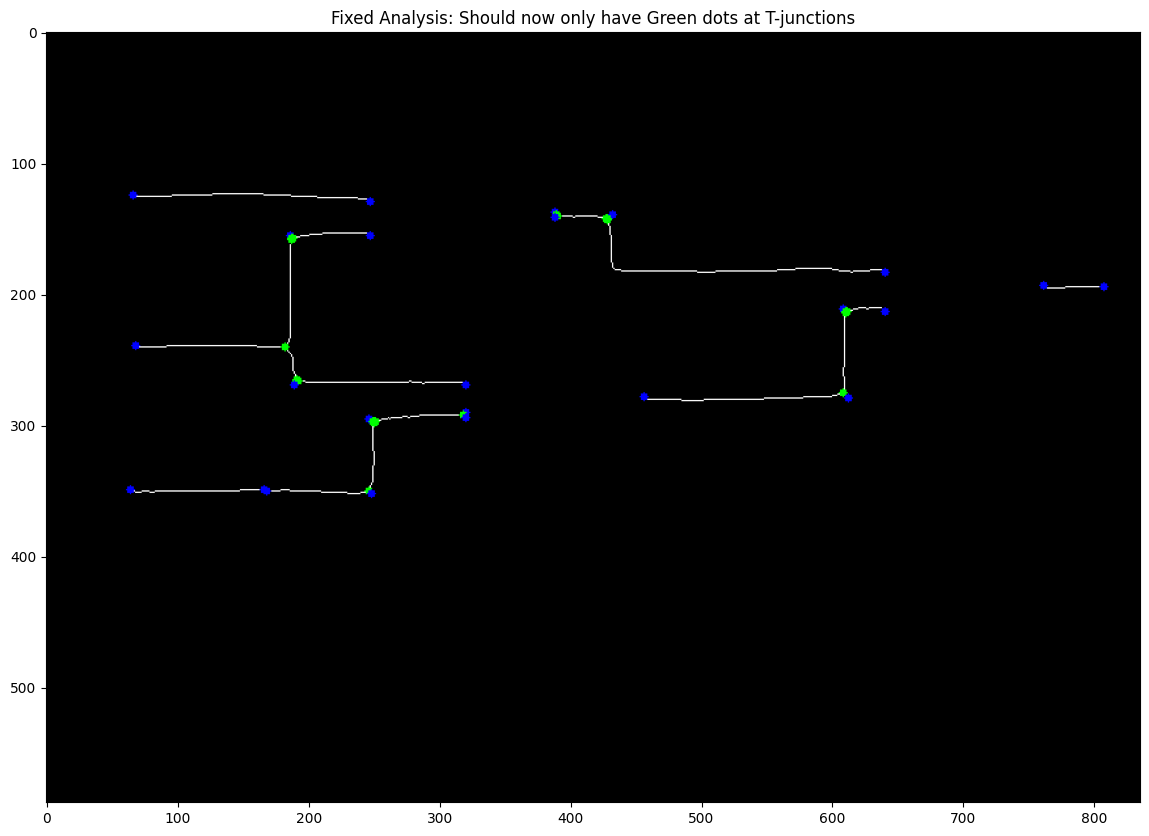

In [34]:
endpoints, junctions, labels = extract_circuit_features(healed_output)

Endpoint and Junction Cleanup

In [35]:
def cleanup_topology_v2(endpoints, junctions, pixel_range=15):
    """
    Advanced topology cleanup including broken line healing.
    """
    new_endpoints = []
    new_junctions = []
    used_endpoints = set()
    
    # --- 1. HANDLE JUNCTION-BASED RULES ---
    for j_coord in junctions:
        jx, jy = j_coord
        nearby_eps = [i for i, (ex, ey) in enumerate(endpoints) 
                    if np.sqrt((jx-ex)**2 + (jy-ey)**2) <= pixel_range]
        
        if len(nearby_eps) >= 2:
            # Rule 1: Junction + 2 EPs = 1 merged EP
            coords = [j_coord] + [endpoints[i] for i in nearby_eps]
            avg_x = int(np.mean([c[0] for c in coords]))
            avg_y = int(np.mean([c[1] for c in coords]))
            new_endpoints.append((avg_x, avg_y))
            for i in nearby_eps: used_endpoints.add(i)
            
        elif len(nearby_eps) == 1:
            # Rule 2: Junction + 1 EP = Bend (Delete both)
            used_endpoints.add(nearby_eps[0])
            # Junction is NOT added to new_junctions
        else:
            # No nearby endpoints, keep the junction
            new_junctions.append(j_coord)

    # --- 2. HANDLE ENDPOINT-TO-ENDPOINT RADIUS (Rule 3) ---
    # We only look at endpoints that weren't already used by junctions
    remaining_ep_indices = [i for i in range(len(endpoints)) if i not in used_endpoints]
    
    final_unused_eps = []
    skip_eps = set()

    for idx_a in remaining_ep_indices:
        if idx_a in skip_eps: continue
        
        ax, ay = endpoints[idx_a]
        found_pair = False
        
        for idx_b in remaining_ep_indices:
            if idx_a == idx_b or idx_b in skip_eps: continue
            
            bx, by = endpoints[idx_b]
            dist = np.sqrt((ax-bx)**2 + (ay-by)**2)
            
            if dist <= pixel_range:
                # Rule 3: EP + EP = Continuous line
                # We "ignore" both, effectively turning them into normal line pixels
                skip_eps.add(idx_a)
                skip_eps.add(idx_b)
                found_pair = True
                break
        
        if not found_pair:
            final_unused_eps.append(endpoints[idx_a])

    # Combine results
    all_final_eps = new_endpoints + final_unused_eps
    
    return all_final_eps, new_junctions

# --- Run the updated version ---
clean_eps, clean_juncs = cleanup_topology_v2(endpoints, junctions, pixel_range=20)

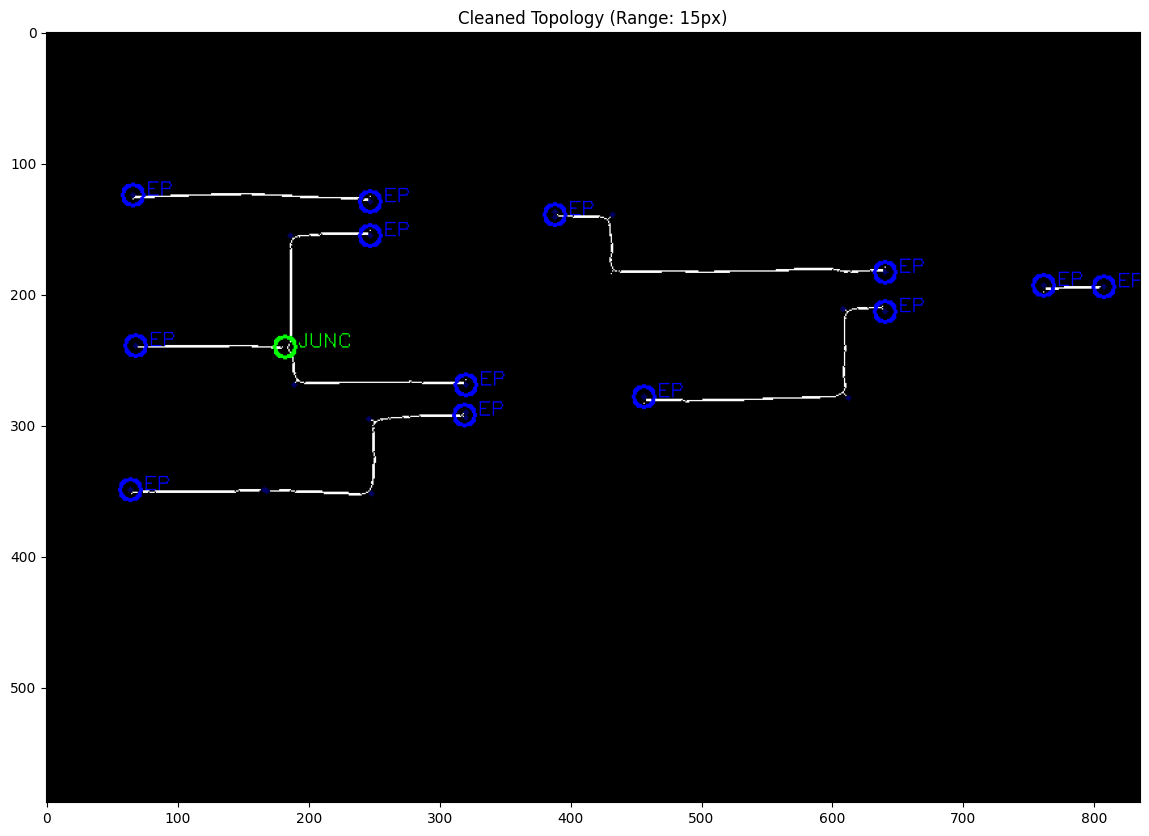

In [37]:
# --- VISUALIZATION ---
pixel_range=15

def visualize_cleanup(img, old_eps, old_juncs, new_eps, new_juncs):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    # Draw original as small dots
    for x, y in old_eps: cv2.circle(vis, (x, y), 2, (100, 0, 0), -1)
    
    # Draw new cleaned features as larger circles
    for x, y in new_eps: 
        cv2.circle(vis, (x, y), 8, (255, 0, 0), 2) # Blue: Clean Endpoints
        cv2.putText(vis, "EP", (x+10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
        
    for x, y in new_juncs: 
        cv2.circle(vis, (x, y), 8, (0, 255, 0), 2) # Green: Clean Junctions
        cv2.putText(vis, "JUNC", (x+10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Cleaned Topology (Range: {pixel_range}px)")
    plt.show()

visualize_cleanup(final_skel, endpoints, junctions, clean_eps, clean_juncs)

In [51]:
def heal_and_relabel_skeleton(skel, endpoints, junctions, pixel_range=20):
    """
    Physically bridges gaps in the skeleton and regenerates the wire_map.
    """
    healed_skel = skel.copy()
    used_indices = set()
    
    # 1. Physical Healing: Draw bridges between endpoints
    # We do this first so the labeling sees one continuous line
    for i in range(len(endpoints)):
        if i in used_indices: continue
        for j in range(i + 1, len(endpoints)):
            if j in used_indices: continue
            
            p1 = endpoints[i]
            p2 = endpoints[j]
            dist = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
            
            if dist <= pixel_range:
                # DRAW the bridge on the skeleton
                cv2.line(healed_skel, p1, p2, 255, 1)
                used_indices.add(i)
                used_indices.add(j)
                break

    # 2. Re-label the image now that gaps are physically closed
    num_labels, wire_map = cv2.connectedComponents(healed_skel)
    
    # 3. Final Topology Cleanup (Spurs and Junction-merging)
    # Re-extract clean coordinates from the new HEALED skeleton
    # using our previous logic for Junctions + Endpoints
    # We re-run the point extraction because the bridges might have 
    # changed neighbor counts.
    
    # [Internal Step: You would call your extract_circuit_features logic here 
    #  on healed_skel to get the new 'final_clean_eps']
    
    return healed_skel, wire_map

# --- Run the fix ---
healed_skel, wire_map = heal_and_relabel_skeleton(final_skel, endpoints, junctions, pixel_range=25)

## Mapping Pins to Gates

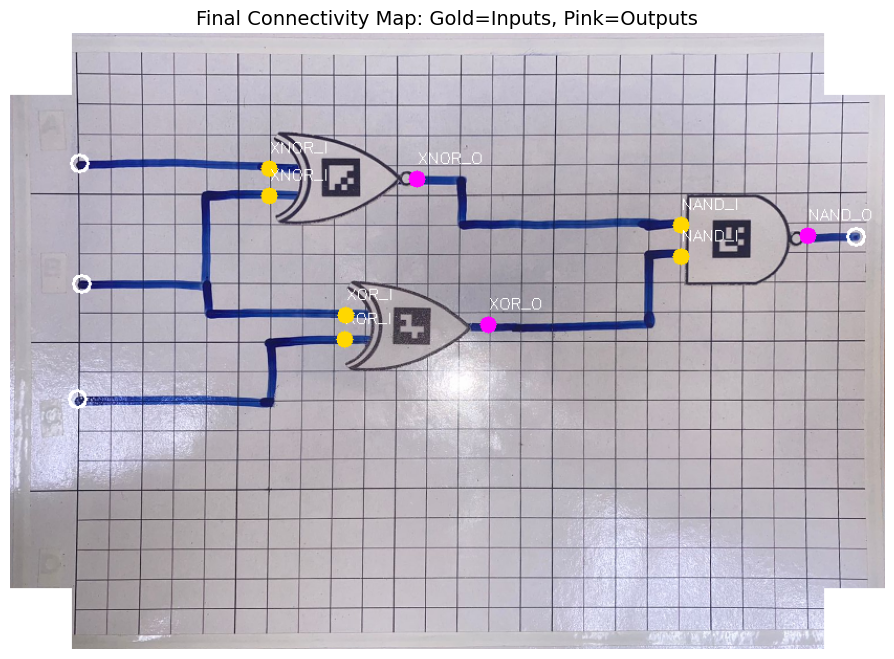


--- Circuit Logical Connections ---
Wire #0 -> XNOR OUTPUT at (388, 139)
Wire #0 -> XNOR OUTPUT at (388, 139)
Wire #0 -> XNOR OUTPUT at (388, 139)
Wire #0 -> XOR INPUT at (319, 292)
Wire #1 -> XNOR INPUT at (np.int64(247), np.int64(129))
Wire #3 -> XNOR INPUT at (np.int64(247), np.int64(155))
Wire #2 -> NAND INPUT at (np.int64(640), np.int64(183))
Wire #4 -> NAND OUTPUT at (np.int64(761), np.int64(193))
Wire #5 -> NAND INPUT at (np.int64(640), np.int64(213))
Wire #3 -> XOR INPUT at (np.int64(320), np.int64(269))
Wire #5 -> XOR OUTPUT at (np.int64(456), np.int64(278))


In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_circuit_netlist(clean_eps, all_detections, wire_labels, search_margin=15):
    """
    Final bridge between the skeleton wires and the ArUco-detected gates.
    """
    final_netlist = []
    
    # We will draw on a copy of the original for the final confirmation
    # Assuming 'warped_image' is your original board image
    vis_final = warped_image.copy()

    for ep_x, ep_y in clean_eps:
        # 1. Identify which wire this point belongs to
        # (Using the 1-pixel thin skeleton labels)
        wire_id = wire_labels[ep_y, ep_x]
        
        assigned = False
        for i, det in enumerate(all_detections):
            x1, y1, x2, y2 = det['bbox']
            
            # Check if Endpoint is within the Gate's "Gravity Field" (bbox + margin)
            if (x1 - search_margin <= ep_x <= x2 + search_margin) and \
            (y1 - search_margin <= ep_y <= y2 + search_margin):
                
                # Logic: Left of center = Input, Right of center = Output
                cx, cy = det['center']
                pin_type = "INPUT" if ep_x < cx else "OUTPUT"
                
                # Store the logical connection
                final_netlist.append({
                    'wire_id': wire_id,
                    'gate_name': det['gate'],
                    'gate_index': i,
                    'pin': pin_type,
                    'coord': (ep_x, ep_y)
                })
                
                # --- Visualization ---
                color = (0, 215, 255) if pin_type == "INPUT" else (255, 0, 255) # Gold/Pink
                cv2.circle(vis_final, (ep_x, ep_y), 8, color, -1)
                cv2.putText(vis_final, f"{det['gate']}_{pin_type[0]}", (ep_x, ep_y-15),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
                assigned = True
                break
        
        if not assigned:
            # Handle points that aren't touching gates (External Connectors)
            final_netlist.append({
                'wire_id': wire_id,
                'gate_name': 'EXTERNAL',
                'gate_index': None,
                'pin': 'IO',
                'coord': (ep_x, ep_y)
            })
            cv2.circle(vis_final, (ep_x, ep_y), 8, (255, 255, 255), 2)

    # --- Display Result ---
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
    plt.title("Final Connectivity Map: Gold=Inputs, Pink=Outputs", fontsize=14)
    plt.axis('off')
    plt.show()

    return final_netlist

# Execute the mapping
circuit_data = generate_circuit_netlist(clean_eps, all_detections, labels)

# Print a human-readable summary
print("\n--- Circuit Logical Connections ---")
for entry in circuit_data:
    if entry['gate_name'] != 'EXTERNAL':
        print(f"Wire #{entry['wire_id']} -> {entry['gate_name']} {entry['pin']} at {entry['coord']}")

In [53]:
def build_logic_netlist(circuit_data):
    """
    Groups individual pin connections into electrical 'Nets'.
    Each net represents a unique signal in the circuit.
    """
    from collections import defaultdict
    
    # Organize everything by Wire ID (Electrical Net)
    nets = defaultdict(lambda: {'sources': [], 'destinations': [], 'external': []})
    
    for entry in circuit_data:
        w_id = entry['wire_id']
        gate_info = f"{entry['gate_name']}_{entry['gate_index']}"
        
        if entry['gate_name'] == 'EXTERNAL':
            nets[w_id]['external'].append(entry['coord'])
        elif entry['pin'] == 'OUTPUT':
            nets[w_id]['sources'].append(gate_info)
        else:
            nets[w_id]['destinations'].append(gate_info)
            
    # Clean up: Convert to a simple list of logical connections
    final_logic = []
    for w_id, data in nets.items():
        # A valid signal usually goes from a Source to a Destination
        if data['sources'] or data['destinations']:
            final_logic.append({
                'net_id': int(w_id),
                'from': data['sources'] if data['sources'] else ["BOARD_INPUT"],
                'to': data['destinations'] if data['destinations'] else ["BOARD_OUTPUT"]
            })
            
    return final_logic

# --- Run the logic extraction ---
logic_circuit = build_logic_netlist(circuit_data)

# --- Print the Final Result ---
print("\n--- FINAL LOGIC NETLIST ---")
for net in logic_circuit:
    src = ", ".join(net['from'])
    dest = ", ".join(net['to'])
    print(f"Signal {net['net_id']}: [{src}] ---> [{dest}]")


--- FINAL LOGIC NETLIST ---
Signal 0: [XNOR_1, XNOR_1, XNOR_1] ---> [XOR_2]
Signal 1: [BOARD_INPUT] ---> [XNOR_1]
Signal 3: [BOARD_INPUT] ---> [XNOR_1, XOR_2]
Signal 2: [BOARD_INPUT] ---> [NAND_0]
Signal 4: [NAND_0] ---> [BOARD_OUTPUT]
Signal 5: [XOR_2] ---> [NAND_0]


# Circuit Identification - Method 2

## Medial Axis

In [52]:
from skimage.morphology import medial_axis

def compute_medial_axis(morphed_image, warped_image=None):
    """
    Computes medial axis from morphologically cleaned binary image.
    Returns medial axis as binary uint8 image.
    """
    morphed_image1 = cv2.bitwise_not(morphed_image)

    if len(morphed_image.shape) == 3:
        gray = cv2.cvtColor(morphed_image1, cv2.COLOR_BGR2GRAY)
    else:
        gray = morphed_image1

    binary = (gray > 0)

    skel, distance = medial_axis(binary, return_distance=True)
    skel_uint8 = (skel * 255).astype(np.uint8)

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    else:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)

    overlay = base.copy()
    overlay[skel] = [255, 255, 255]  # Red medial axis on top of original

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Morphed Input')
    axes[0].axis('off')

    axes[1].imshow(skel_uint8, cmap='gray')
    axes[1].set_title('Medial Axis (raw)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Medial Axis overlaid on original')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return skel_uint8

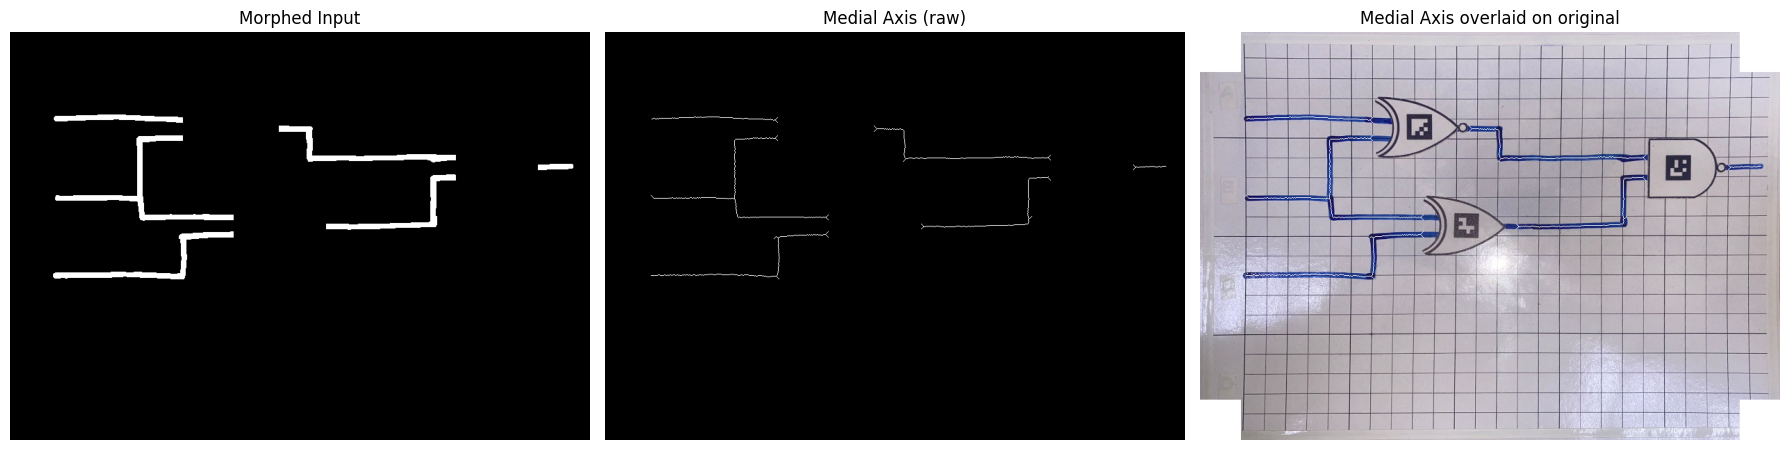

In [54]:
medial_skel = compute_medial_axis(closed2, warped_image=warped_image)

In [58]:
from skimage.morphology import medial_axis
import matplotlib.patches as mpatches

def extract_circuit_features(skel_uint8, warped_image=None):
    """
    Takes medial axis binary image, extracts wires, endpoints, junctions.
    Prints Wire report: Wire01 --- EP01.1 (x,y) --- JUNC01.1 (x,y)
    """
    num_labels, labels = cv2.connectedComponents(skel_uint8)

    base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB) if warped_image is not None else cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    vis_img = base.copy()

    padded_skel = np.pad(skel_uint8, 1, mode='constant', constant_values=0)
    white_pixels = np.argwhere(skel_uint8 > 0)

    wire_data = {}
    for wire_id in range(1, num_labels):
        wire_data[wire_id] = {'endpoints': [], 'junctions': [], 'pixels': []}

    for y, x in white_pixels:
        neighborhood = padded_skel[y:y+3, x:x+3]
        neighbor_count = np.sum(neighborhood > 0) - 1
        wire_id = int(labels[y, x])

        wire_data[wire_id]['pixels'].append((x, y))

        if neighbor_count == 1:
            wire_data[wire_id]['endpoints'].append((x, y))
            cv2.circle(vis_img, (x, y), 4, (0, 0, 255), -1)

        elif neighbor_count >= 3:
            wire_data[wire_id]['junctions'].append((x, y))
            cv2.circle(vis_img, (x, y), 4, (0, 255, 0), -1)

    # ── Remove wires with no endpoints and no junctions ───────────────────────
    wire_data = {wid: data for wid, data in wire_data.items()
                if data['endpoints'] or data['junctions']}

    # ── Label each wire at its centroid ───────────────────────────────────────
    for wire_id, data in wire_data.items():
        if data['pixels']:
            cx = int(np.mean([p[0] for p in data['pixels']]))
            cy = int(np.mean([p[1] for p in data['pixels']]))
            cv2.putText(vis_img, f"W{wire_id:02d}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)

    # ── Visualization ─────────────────────────────────────────────────────────
    blue_patch   = mpatches.Patch(color='blue',   label='Endpoint')
    green_patch  = mpatches.Patch(color='green',  label='Junction')
    yellow_patch = mpatches.Patch(color='yellow', label='Wire label')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title('Circuit Features: Blue=Endpoint  Green=Junction  Yellow=Wire ID')
    plt.legend(handles=[blue_patch, green_patch, yellow_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    for wire_id, data in wire_data.items():
        wid = f"Wire{wire_id:02d}"

        ep_str   = ', '.join(f"EP{wire_id:02d}.{i+1} {pt}"   for i, pt in enumerate(data['endpoints']))  or '-'
        junc_str = ', '.join(f"JUNC{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['junctions'])) or '-'

        print(f"{wid} --- {ep_str} --- {junc_str}")

    return wire_data, labels

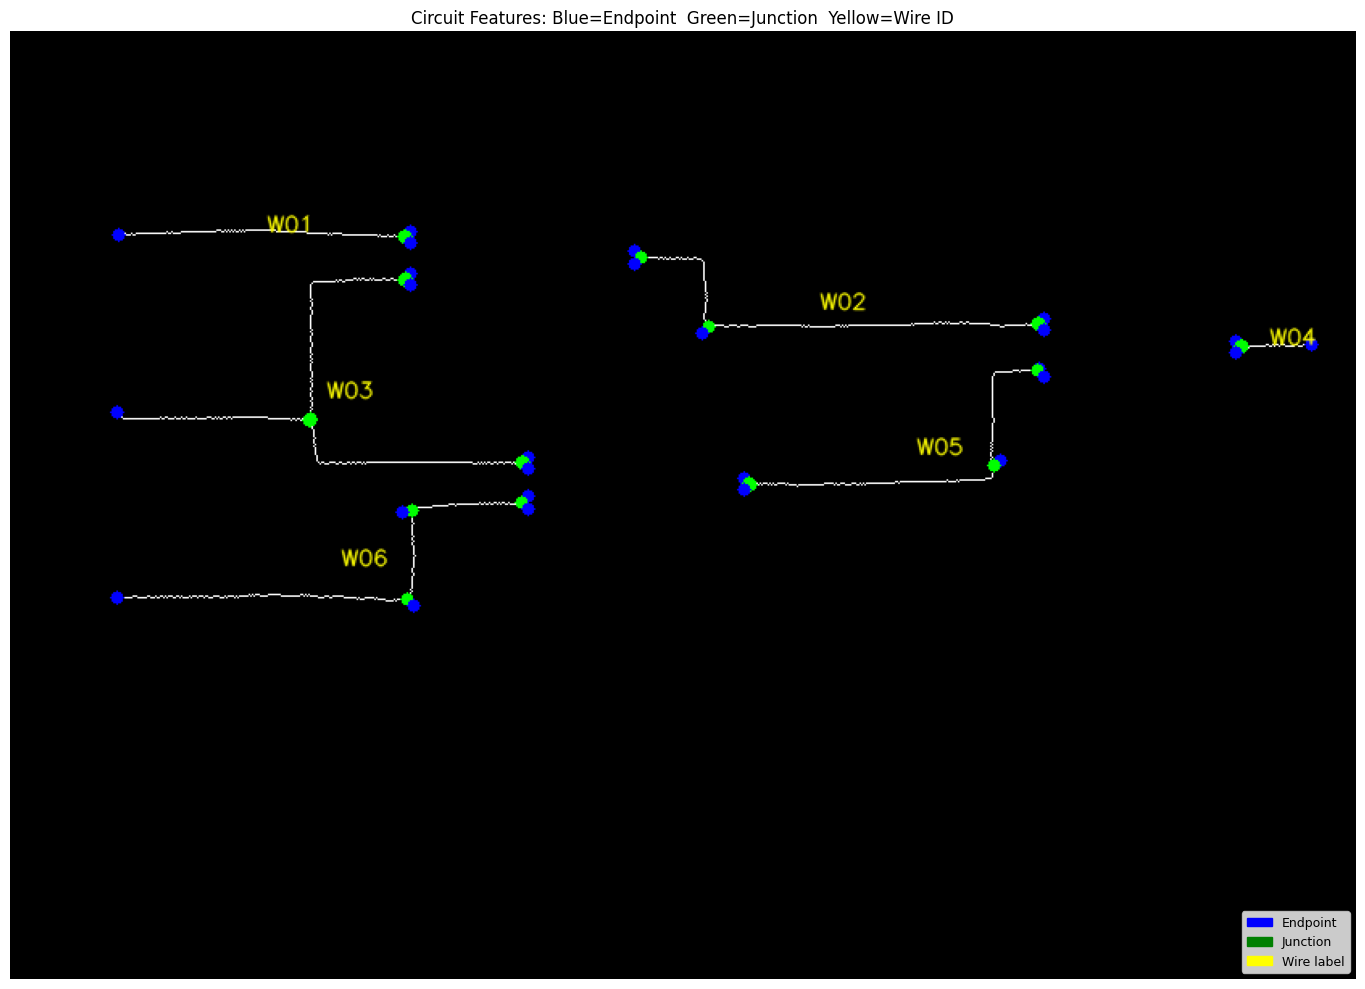

Wire01 --- EP01.1 (np.int64(248), np.int64(124)), EP01.2 (np.int64(67), np.int64(126)), EP01.3 (np.int64(248), np.int64(131)) --- JUNC01.1 (np.int64(244), np.int64(127)), JUNC01.2 (np.int64(245), np.int64(127)), JUNC01.3 (np.int64(245), np.int64(128))
Wire02 --- EP02.1 (np.int64(387), np.int64(136)), EP02.2 (np.int64(387), np.int64(144)), EP02.3 (np.int64(641), np.int64(178)), EP02.4 (np.int64(641), np.int64(185)), EP02.5 (np.int64(429), np.int64(187)) --- JUNC02.1 (np.int64(391), np.int64(140)), JUNC02.2 (np.int64(637), np.int64(181)), JUNC02.3 (np.int64(638), np.int64(181)), JUNC02.4 (np.int64(638), np.int64(182)), JUNC02.5 (np.int64(433), np.int64(183))
Wire03 --- EP03.1 (np.int64(248), np.int64(150)), EP03.2 (np.int64(248), np.int64(157)), EP03.3 (np.int64(66), np.int64(236)), EP03.4 (np.int64(321), np.int64(264)), EP03.5 (np.int64(321), np.int64(271)) --- JUNC03.1 (np.int64(245), np.int64(153)), JUNC03.2 (np.int64(244), np.int64(154)), JUNC03.3 (np.int64(245), np.int64(154)), JUNC

In [59]:
wire_data, labels = extract_circuit_features(medial_skel, warped_image=None)

In [62]:
def cleanup_webbing(wire_data, pixel_range=5, warped_image=None, skel_uint8=None):
    """
    Cleans up webbing artifacts:
    Rule 1: 1+ junctions + 1 endpoint within pixel_range → remove all
    Rule 2: 1+ junctions + 2 endpoints within pixel_range → remove all, add 1 midpoint endpoint
    Rule 3: 2+ junctions within pixel_range → merge into single junction at centroid
    """
    def dist(p1, p2):
        return np.hypot(p1[0] - p2[0], p1[1] - p2[1])

    all_eps   = [(pt, wid) for wid, data in wire_data.items() for pt in data['endpoints']]
    all_juncs = [(pt, wid) for wid, data in wire_data.items() for pt in data['junctions']]

    removed_eps   = set()
    removed_juncs = set()
    added_eps     = []
    added_juncs   = []

    visited_juncs = set()

    for ji, (jpt, jwid) in enumerate(all_juncs):
        if ji in visited_juncs:
            continue

        # ── Find all junctions within pixel_range of this junction ────────────
        nearby_juncs = [ji]
        for ji2, (jpt2, jwid2) in enumerate(all_juncs):
            if ji2 != ji and ji2 not in visited_juncs and dist(jpt, jpt2) <= pixel_range:
                nearby_juncs.append(ji2)

        # ── Find all endpoints within pixel_range of any nearby junction ───────
        nearby_eps = []
        for ji2 in nearby_juncs:
            jpt2 = all_juncs[ji2][0]
            for ei, (ept, ewid) in enumerate(all_eps):
                if ei not in removed_eps and dist(jpt2, ept) <= pixel_range:
                    if ei not in [e[0] for e in nearby_eps]:
                        nearby_eps.append((ei, ept, ewid))

        n_eps  = len(nearby_eps)
        n_junc = len(nearby_juncs)

        if n_eps == 1:
            # Rule 1: bend → remove everything
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            removed_eps.add(nearby_eps[0][0])

        elif n_eps == 2:
            # Rule 2: 2 endpoints → remove everything, add midpoint endpoint
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            ei1, ep1, wid1 = nearby_eps[0]
            ei2, ep2, wid2 = nearby_eps[1]
            removed_eps.add(ei1)
            removed_eps.add(ei2)
            mid = (int((ep1[0] + ep2[0]) // 2), int((ep1[1] + ep2[1]) // 2))
            added_eps.append((mid, wid1))

        elif n_eps == 0 and n_junc >= 2:
            # Rule 3: 2+ junctions, no endpoints → merge into one junction at centroid
            cx = int(np.mean([all_juncs[ji2][0][0] for ji2 in nearby_juncs]))
            cy = int(np.mean([all_juncs[ji2][0][1] for ji2 in nearby_juncs]))
            for ji2 in nearby_juncs:
                removed_juncs.add(ji2)
                visited_juncs.add(ji2)
            added_juncs.append(((cx, cy), jwid))

        else:
            for ji2 in nearby_juncs:
                visited_juncs.add(ji2)

    # ── Rebuild wire_data ─────────────────────────────────────────────────────
    new_wire_data = {wid: {'endpoints': [], 'junctions': [], 'pixels': data['pixels']}
                     for wid, data in wire_data.items()}

    for i, (pt, wid) in enumerate(all_eps):
        if i not in removed_eps:
            new_wire_data[wid]['endpoints'].append(pt)

    for i, (pt, wid) in enumerate(all_juncs):
        if i not in removed_juncs:
            new_wire_data[wid]['junctions'].append(pt)

    for pt, wid in added_eps:
        new_wire_data[wid]['endpoints'].append(pt)

    for pt, wid in added_juncs:
        new_wire_data[wid]['junctions'].append(pt)

    new_wire_data = {wid: data for wid, data in new_wire_data.items()
                     if data['endpoints'] or data['junctions']}

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    elif skel_uint8 is not None:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    else:
        h = max((pt[1] for pt, _ in all_eps + all_juncs), default=600) + 20
        w = max((pt[0] for pt, _ in all_eps + all_juncs), default=800) + 20
        base = np.zeros((h, w, 3), dtype=np.uint8)

    vis_img = base.copy()

    if skel_uint8 is not None:
        vis_img[skel_uint8 > 0] = [180, 180, 180]

    for wid, data in new_wire_data.items():
        for pt in data['endpoints']:
            cv2.circle(vis_img, pt, 4, (0, 0, 255), -1)
        for pt in data['junctions']:
            cv2.circle(vis_img, pt, 4, (0, 255, 0), -1)
        if data['pixels']:
            cx = int(np.mean([p[0] for p in data['pixels']]))
            cy = int(np.mean([p[1] for p in data['pixels']]))
            cv2.putText(vis_img, f"W{wid:02d}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv2.LINE_AA)

    blue_patch   = mpatches.Patch(color='blue',   label='Endpoint')
    green_patch  = mpatches.Patch(color='green',  label='Junction')
    yellow_patch = mpatches.Patch(color='yellow', label='Wire ID')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title(f'After Webbing Cleanup (pixel_range={pixel_range}): Blue=Endpoint  Green=Junction')
    plt.legend(handles=[blue_patch, green_patch, yellow_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    for wire_id, data in new_wire_data.items():
        wid      = f"Wire{wire_id:02d}"
        ep_str   = ', '.join(f"EP{wire_id:02d}.{i+1} {pt}"   for i, pt in enumerate(data['endpoints']))  or '-'
        junc_str = ', '.join(f"JUNC{wire_id:02d}.{i+1} {pt}" for i, pt in enumerate(data['junctions'])) or '-'
        print(f"{wid} --- {ep_str} --- {junc_str}")

    return new_wire_data

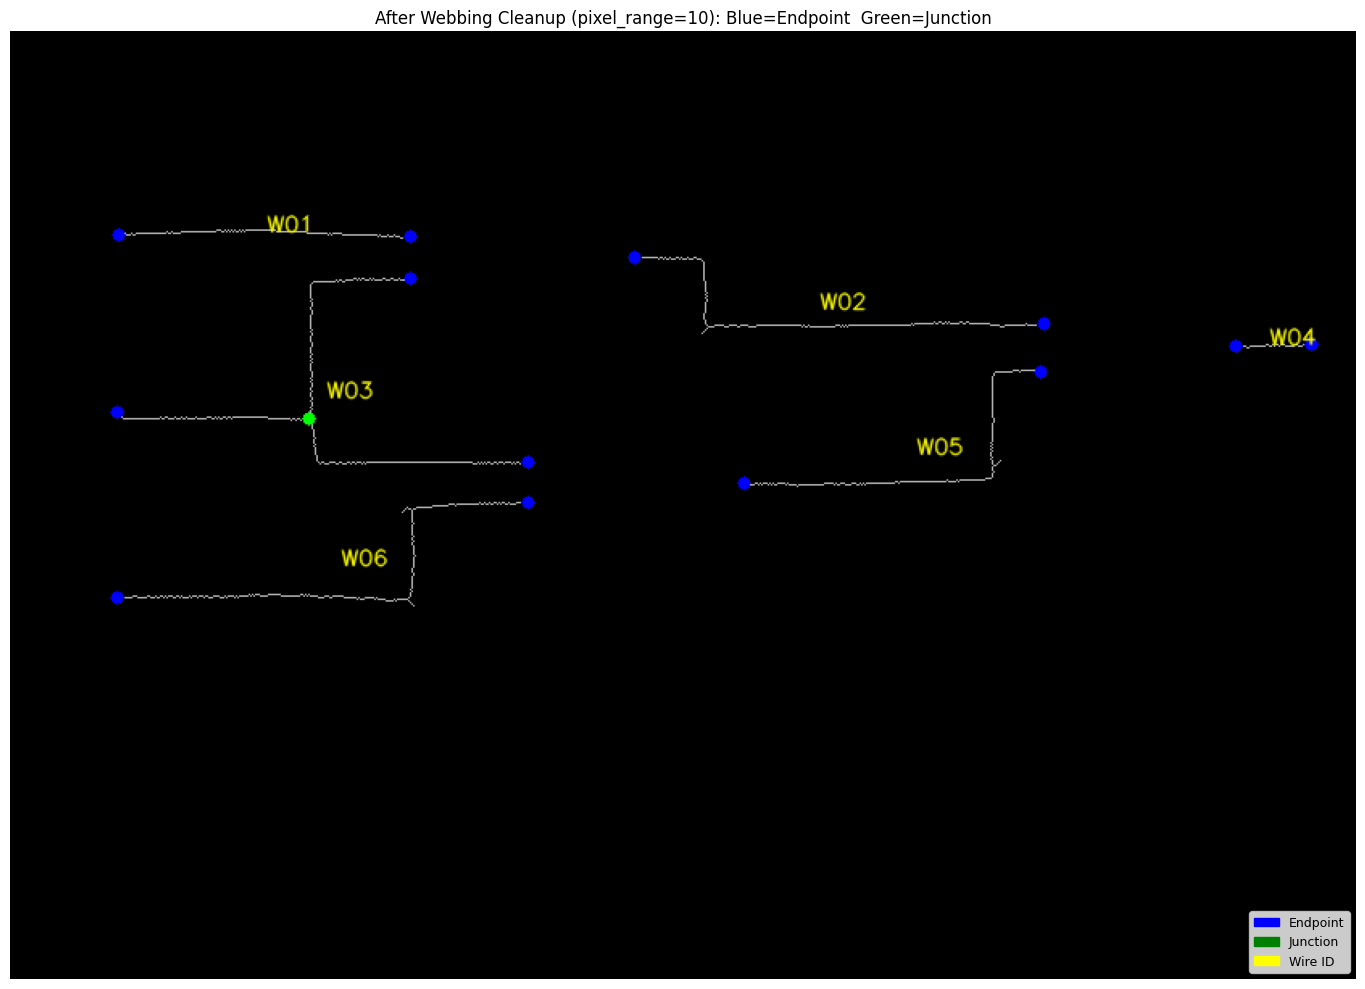

Wire01 --- EP01.1 (np.int64(67), np.int64(126)), EP01.2 (248, 127) --- -
Wire02 --- EP02.1 (387, 140), EP02.2 (641, 181) --- -
Wire03 --- EP03.1 (np.int64(66), np.int64(236)), EP03.2 (248, 153), EP03.3 (321, 267) --- JUNC03.1 (185, 240)
Wire04 --- EP04.1 (np.int64(807), np.int64(194)), EP04.2 (760, 195) --- -
Wire05 --- EP05.1 (639, 211), EP05.2 (455, 280) --- -
Wire06 --- EP06.1 (np.int64(66), np.int64(351)), EP06.2 (321, 292) --- -


In [63]:
new_wire_data = cleanup_webbing(wire_data, pixel_range=10, warped_image=None , skel_uint8=medial_skel)

In [64]:
def identify_circuit_io(new_wire_data, all_detections, warped_image=None, skel_uint8=None, gate_margin=5):
    """
    Identifies circuit inputs and output from remaining wire endpoints.
    Step 1: Discard endpoints within gate_margin px of any gate bbox
    Step 2: Compute midpoint from leftmost/rightmost remaining endpoint x
    Step 3: Endpoints left of mid → inputs, labelled A, B, C... top to bottom
    Step 4: Endpoints right of mid → should be exactly 1, labelled O
    """

    # ── Flatten all endpoints ─────────────────────────────────────────────────
    all_eps = [(pt, wid) for wid, data in new_wire_data.items() for pt in data['endpoints']]

    # ── Step 1: Filter out endpoints near/on/in gate bboxes ──────────────────
    def near_bbox(pt, bbox, margin):
        x, y = pt
        x1, y1, x2, y2 = bbox
        return (x >= x1 - margin and x <= x2 + margin and
                y >= y1 - margin and y <= y2 + margin)

    remaining_eps = [(pt, wid) for pt, wid in all_eps
                     if not any(near_bbox(pt, det['bbox'], gate_margin)
                                for det in all_detections)]

    if not remaining_eps:
        print("No endpoints remaining after filtering gate bboxes.")
        return {}, {}

    # ── Step 2: Compute midpoint from wire area ───────────────────────────────
    xs = [pt[0] for pt, _ in remaining_eps]
    mid_x = (min(xs) + max(xs)) // 2

    # ── Step 3 & 4: Split into inputs and outputs ─────────────────────────────
    left_eps  = sorted([(pt, wid) for pt, wid in remaining_eps if pt[0] <= mid_x], key=lambda e: e[0][1])
    right_eps = [(pt, wid) for pt, wid in remaining_eps if pt[0] > mid_x]

    inputs  = {}
    outputs = {}

    for i, (pt, wid) in enumerate(left_eps):
        label = chr(65 + i)  # A, B, C...
        inputs[label] = {'point': pt, 'wire_id': wid}

    if len(right_eps) == 0:
        print("ERROR: No output endpoint found on the right side.")
    elif len(right_eps) > 1:
        print(f"ERROR: Multiple output endpoints found ({len(right_eps)}), expected exactly 1.")
        for pt, wid in right_eps:
            print(f"  Wire{wid:02d} at {pt}")
    else:
        pt, wid = right_eps[0]
        outputs['O'] = {'point': pt, 'wire_id': wid}

    # ── Visualization ─────────────────────────────────────────────────────────
    if warped_image is not None:
        base = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB).copy()
    elif skel_uint8 is not None:
        base = cv2.cvtColor(skel_uint8, cv2.COLOR_GRAY2RGB)
    else:
        h = max((pt[1] for pt, _ in all_eps), default=600) + 20
        w = max((pt[0] for pt, _ in all_eps), default=800) + 20
        base = np.zeros((h, w, 3), dtype=np.uint8)

    vis_img = base.copy()

    if skel_uint8 is not None:
        vis_img[skel_uint8 > 0] = [180, 180, 180]

    # Draw midline
    cv2.line(vis_img, (mid_x, 0), (mid_x, vis_img.shape[0]), (200, 200, 0), 1)

    for label, data in inputs.items():
        pt = data['point']
        cv2.circle(vis_img, pt, 6, (0, 0, 255), -1)
        cv2.putText(vis_img, label, (pt[0] + 6, pt[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)

    for label, data in outputs.items():
        pt = data['point']
        cv2.circle(vis_img, pt, 6, (0, 255, 0), -1)
        cv2.putText(vis_img, label, (pt[0] + 6, pt[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

    red_patch   = mpatches.Patch(color='blue',  label='Circuit Input')
    green_patch = mpatches.Patch(color='green', label='Circuit Output')

    plt.figure(figsize=(15, 10))
    plt.imshow(vis_img)
    plt.title('Circuit I/O: Blue=Input  Green=Output  Yellow=Midline')
    plt.legend(handles=[red_patch, green_patch], loc='lower right', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Print report ──────────────────────────────────────────────────────────
    print("── Circuit Inputs ────────────────────────────────────────────────")
    for label, data in inputs.items():
        print(f"  {label} → Wire{data['wire_id']:02d} at {data['point']}")

    print("── Circuit Output ────────────────────────────────────────────────")
    for label, data in outputs.items():
        print(f"  {label} → Wire{data['wire_id']:02d} at {data['point']}")

    return inputs, outputs

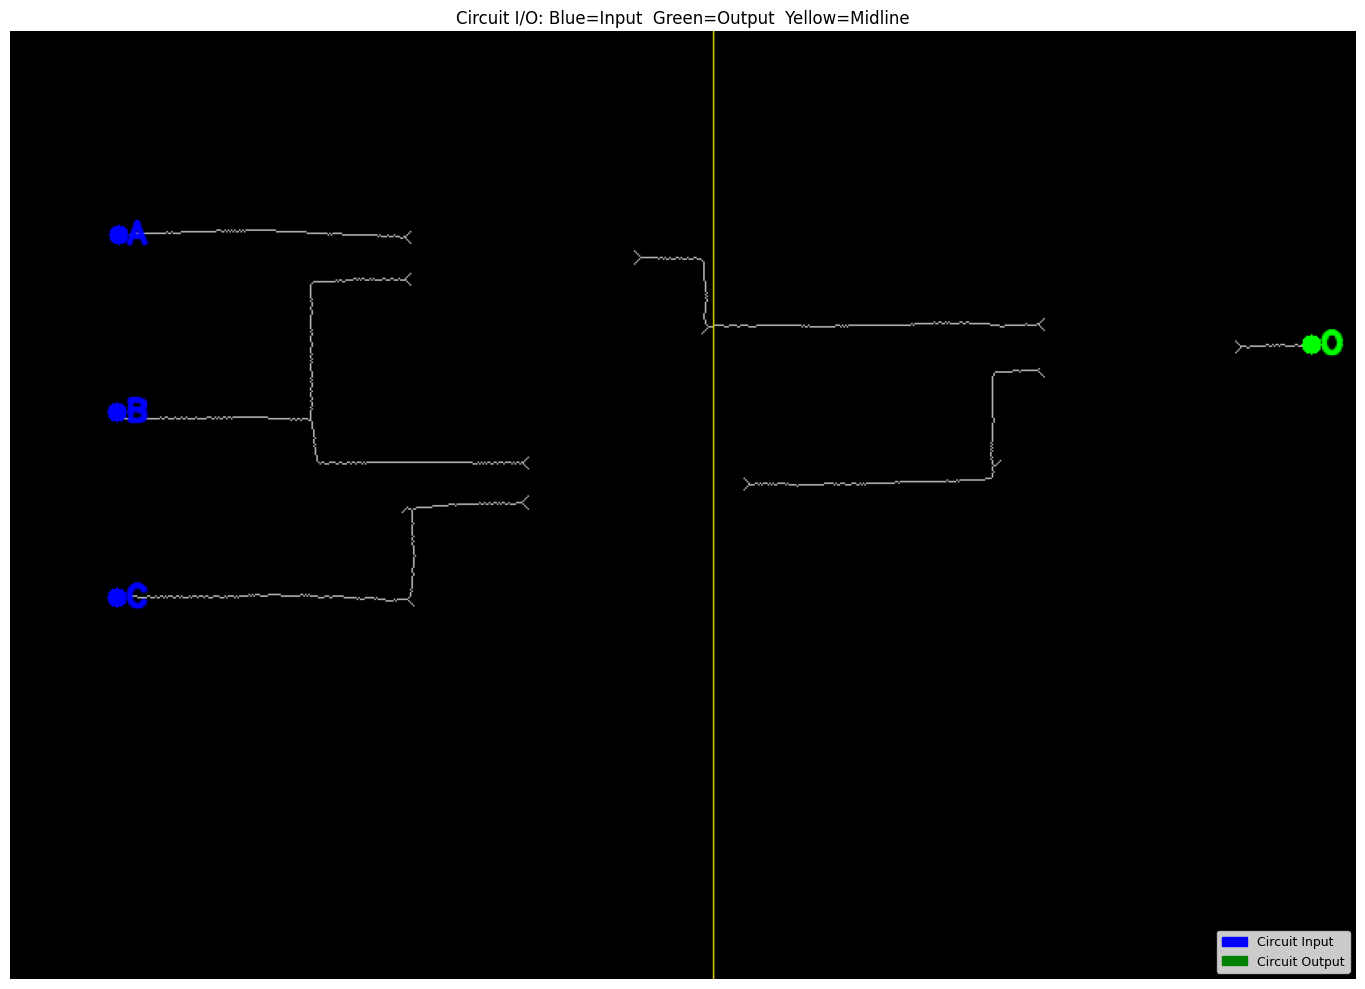

── Circuit Inputs ────────────────────────────────────────────────
  A → Wire01 at (np.int64(67), np.int64(126))
  B → Wire03 at (np.int64(66), np.int64(236))
  C → Wire06 at (np.int64(66), np.int64(351))
── Circuit Output ────────────────────────────────────────────────
  O → Wire04 at (np.int64(807), np.int64(194))


In [65]:
inputs, outputs = identify_circuit_io(new_wire_data, all_detections, warped_image=None, skel_uint8=medial_skel, gate_margin=5)

In [66]:
def build_boolean_expression(new_wire_data, all_detections, inputs, outputs, port_margin=5):
    """
    Builds a Boolean expression from wire graph.
    Step 1: Build gate port positions
    Step 2: Assign wires to gate ports
    Step 3: Build directed graph
    Step 4: Recursive expression from output
    """

    def dist(p1, p2):
        return np.hypot(p1[0] - p2[0], p1[1] - p2[1])

    # ── Step 1: Define port positions per gate ────────────────────────────────
    # input ports: left edge center + upper/lower left for 2-input gates
    # output port: right edge center
    TWO_INPUT_GATES = {'AND', 'NAND', 'OR', 'NOR', 'XOR', 'XNOR'}
    ONE_INPUT_GATES = {'NOT', 'BUFFER'}

    gate_ports = []
    for det in all_detections:
        x1, y1, x2, y2 = det['bbox']
        mid_y = (y1 + y2) // 2
        name  = det['gate']

        if name in TWO_INPUT_GATES:
            ports = {
                'in1': (x1, (y1 + mid_y) // 2),   # upper left
                'in2': (x1, (mid_y + y2) // 2),    # lower left
                'out': (x2, mid_y),                 # right center
            }
        else:
            ports = {
                'in1': (x1, mid_y),                 # left center
                'out': (x2, mid_y),                 # right center
            }

        gate_ports.append({
            'gate'  : name,
            'id'    : det['id'],
            'center': det['center'],
            'ports' : ports,
        })

    # ── Step 2: Assign wires to gate ports ────────────────────────────────────
    # Collect all wire points: endpoints + junctions
    wire_points = {}
    for wid, data in new_wire_data.items():
        wire_points[wid] = data['endpoints'] + data['junctions']

    # For each gate port find which wire is closest within port_margin
    for gp in gate_ports:
        gp['wire_map'] = {}
        for port_name, port_pos in gp['ports'].items():
            best_wid, best_d = None, port_margin
            for wid, pts in wire_points.items():
                for pt in pts:
                    d = dist(port_pos, pt)
                    if d <= best_d:
                        best_d  = d
                        best_wid = wid
            gp['wire_map'][port_name] = best_wid

    # ── Step 3: Build directed graph ──────────────────────────────────────────
    # wire_id → gate that outputs onto it
    wire_source = {}
    for gp in gate_ports:
        out_wire = gp['wire_map'].get('out')
        if out_wire is not None:
            wire_source[out_wire] = gp

    # circuit input wire ids
    input_wire_map = {data['wire_id']: label for label, data in inputs.items()}

    # ── Step 4: Recursive expression builder ──────────────────────────────────
    memo = {}

    def resolve(wire_id):
        if wire_id is None:
            return '?'
        if wire_id in memo:
            return memo[wire_id]

        # Base case: circuit input
        if wire_id in input_wire_map:
            return input_wire_map[wire_id]

        # Find gate that drives this wire
        if wire_id not in wire_source:
            return f'W{wire_id:02d}?'

        gp   = wire_source[wire_id]
        name = gp['gate']
        wmap = gp['wire_map']

        in1 = resolve(wmap.get('in1'))
        in2 = resolve(wmap.get('in2')) if 'in2' in wmap else None

        if name == 'NOT':
            expr = f'(NOT {in1})'
        elif name == 'BUFFER':
            expr = f'{in1}'
        elif name == 'AND':
            expr = f'({in1} AND {in2})'
        elif name == 'NAND':
            expr = f'(NOT ({in1} AND {in2}))'
        elif name == 'OR':
            expr = f'({in1} OR {in2})'
        elif name == 'NOR':
            expr = f'(NOT ({in1} OR {in2}))'
        elif name == 'XOR':
            expr = f'({in1} XOR {in2})'
        elif name == 'XNOR':
            expr = f'(NOT ({in1} XOR {in2}))'
        else:
            expr = f'{name}({in1})'

        memo[wire_id] = expr
        return expr

    # ── Resolve from output wire ───────────────────────────────────────────────
    if not outputs:
        print("ERROR: No circuit output defined.")
        return None

    out_wire_id = outputs['O']['wire_id']
    expression  = resolve(out_wire_id)

    # ── Print report ──────────────────────────────────────────────────────────
    print("── Gate Port Assignments ─────────────────────────────────────────")
    for gp in gate_ports:
        print(f"  {gp['gate']:6s} | ", end='')
        for port, wid in gp['wire_map'].items():
            print(f"{port}→W{wid:02d} " if wid else f"{port}→None ", end='')
        print()

    print("\n── Boolean Expression ────────────────────────────────────────────")
    print(f"  O = {expression}")

    return expression

In [68]:
expression = build_boolean_expression(new_wire_data, all_detections, inputs, outputs, port_margin=20)

── Gate Port Assignments ─────────────────────────────────────────
  NAND   | in1→W02 in2→W05 out→W04 
  XNOR   | in1→W01 in2→W03 out→W02 
  XOR    | in1→W03 in2→W06 out→W05 

── Boolean Expression ────────────────────────────────────────────
  O = (NOT ((NOT (A XOR B)) AND (B XOR C)))
